# Final Exam BUS 458 — Loan Data Analysis
**Objective:** Your objective is to identify the key drivers of loan approval and recommend which lender should be prioritized for each customer to maximize total payout

### **Instructions**
- Follow the prompts in each section of this notebook.
- **Where you see a “Question,” answer it directly below in a Markdown (text) cell — not as a code comment.**
- Your **reasoning, interpretations, and insights** should be written in text cells, clearly separated from code.
- You are encouraged to add extra **code cells**, **visualizations**, or **short explanations** if they strengthen your analysis or help you justify decisions.
- Make sure your notebook runs cleanly from start to finish without errors.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load Data (via Google Drive or direct upload)

In [ ]:
df = pd.read_csv('/loan_data_analysis_final.csv')

In [ ]:
# Check first 5 rows of dataframe
# Add your code here
df.head(5)

,User ID,applications,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,00007820-89cb-4c1d-9940-eb270d605a35,1,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,00012b55-514c-421e-9c76-3300abbc1134,1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,000157c1-b6a3-4c86-82c7-9ec1bda3799a,1,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,00020400-efab-4b10-8812-2a0aaf774841,1,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,0002f737-0cda-48fb-91ed-533f3d0eab05,1,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0


In [ ]:
# Drop columns that have no variation or are unique
# 'applications' has no variation
# 'User ID' is a unique identifier


columns_to_drop = ['applications', 'User ID']
df = df.drop(columns=columns_to_drop, errors='ignore')

print(f"Columns dropped: {columns_to_drop}")
print("DataFrame columns after dropping:")
print(df.columns)

df.head(5)

Columns dropped: ['applications', 'User ID']
DataFrame columns after dropping:
Index(['Reason', 'Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score',
       'Fico_Score_group', 'Employment_Status', 'Employment_Sector',
       'Monthly_Gross_Income', 'Monthly_Housing_Payment',
       'Ever_Bankrupt_or_Foreclose', 'Lender', 'Approved', 'bounty'],
      dtype='object')


,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0


Understand the Data: Get a quick overview of the dataset structure and variable meanings before preprocessing.

In [ ]:
# Display general information about the DataFrame
print("DataFrame Info:")
df.info()




DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Reason                      100000 non-null  object 
 1   Granted_Loan_Amount         100000 non-null  int64  
 2   Requested_Loan_Amount       100000 non-null  float64
 3   FICO_score                  85000 non-null   float64
 4   Fico_Score_group            100000 non-null  object 
 5   Employment_Status           100000 non-null  object 
 6   Employment_Sector           93593 non-null   object 
 7   Monthly_Gross_Income        85000 non-null   float64
 8   Monthly_Housing_Payment     100000 non-null  int64  
 9   Ever_Bankrupt_or_Foreclose  100000 non-null  int64  
 10  Lender                      100000 non-null  object 
 11  Approved                    100000 non-null  int64  
 12  bounty                      100000 non-null  int64  
dtyp

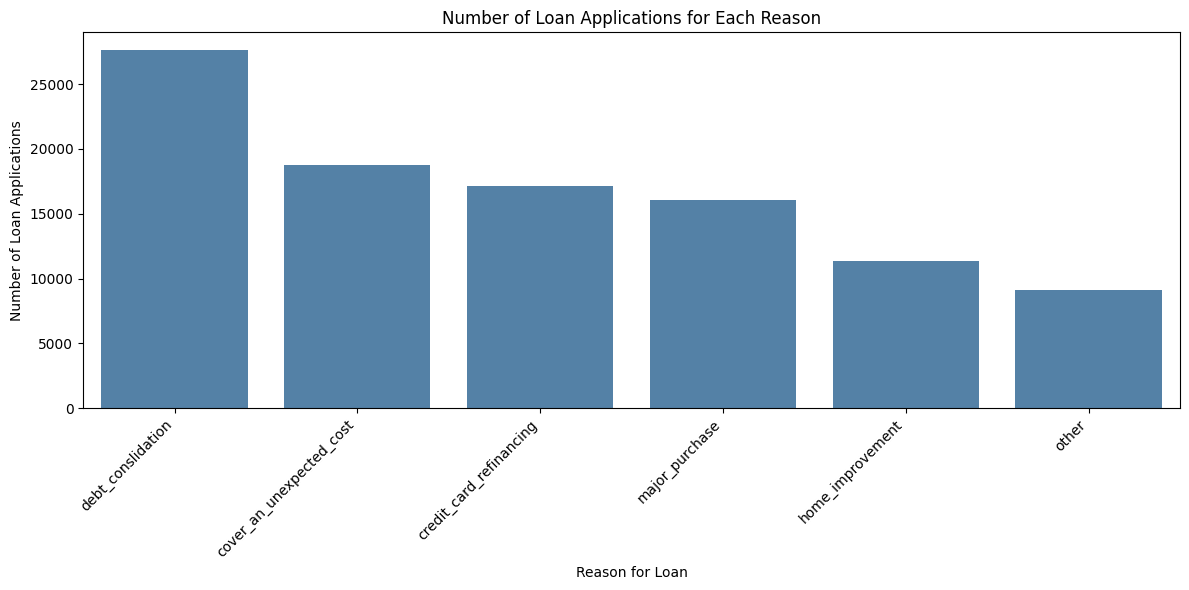

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Reason', data=df, color='steelblue', order=df['Reason'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Loan Applications')
plt.xlabel('Reason for Loan')
plt.title('Number of Loan Applications for Each Reason')
plt.tight_layout()
plt.savefig('reason_count.png', bbox_inches='tight', dpi=300)
plt.show()

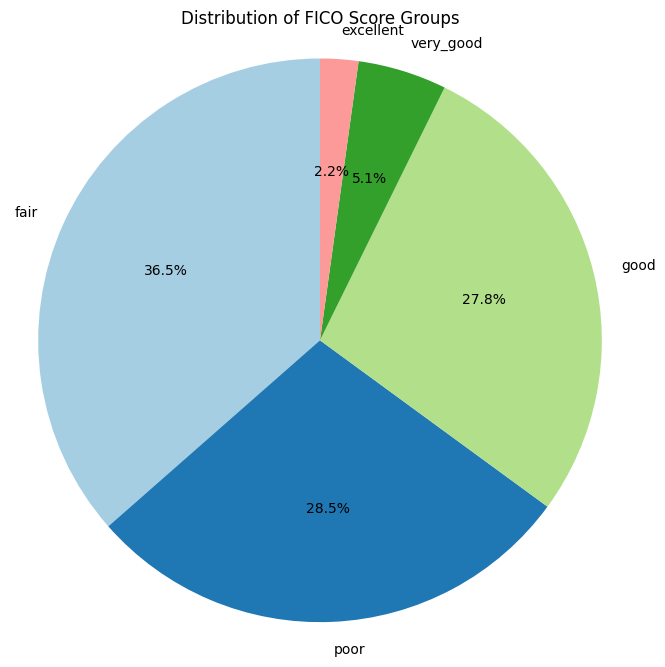

In [ ]:
# Calculate the value counts for 'Fico_Score_group'
fico_group_counts = df['Fico_Score_group'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(fico_group_counts, labels=fico_group_counts.index, autopct='%1.1f%%', colors=plt.cm.Paired.colors, startangle=90)
plt.title('Distribution of FICO Score Groups')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.savefig('fico_score_group_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_25691/805761478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Approved', data=df, palette='viridis')


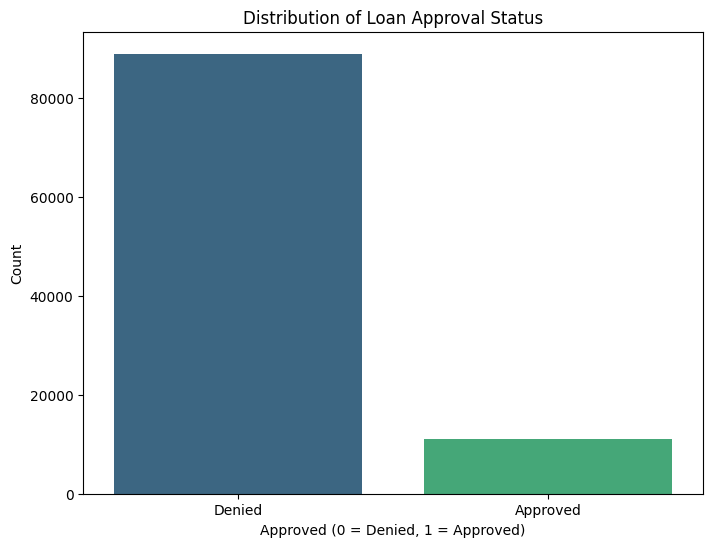

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Approved', data=df, palette='viridis')
plt.title('Distribution of Loan Approval Status')
plt.xlabel('Approved (0 = Denied, 1 = Approved)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Denied', 'Approved'])
plt.show()

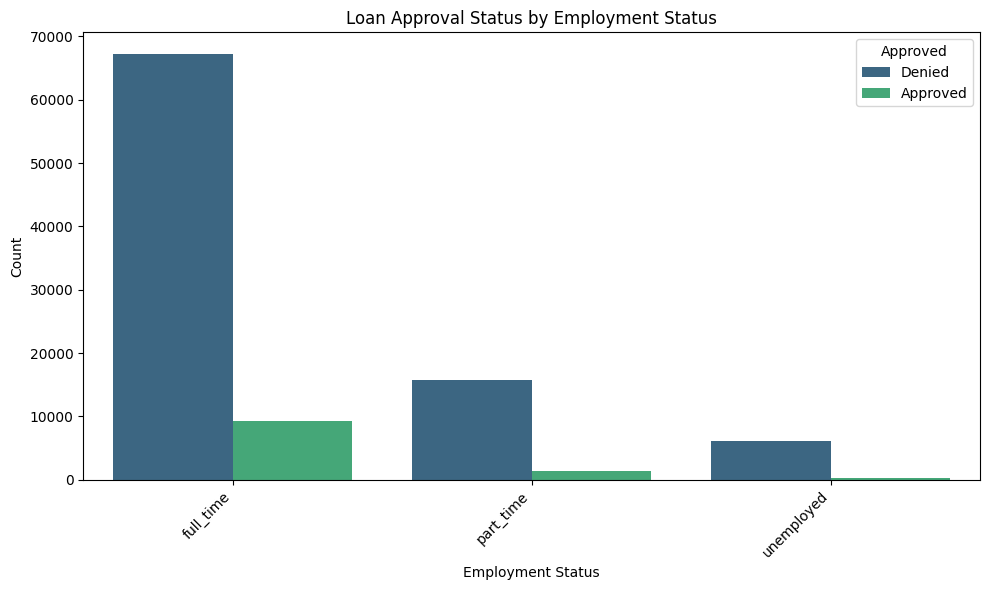

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Employment_Status', hue='Approved', data=df, palette='viridis')
plt.title('Loan Approval Status by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Approved', labels=['Denied', 'Approved'])
plt.tight_layout()
plt.show()

## 1. Preprocessing


### 1.1 Handling Missing Values

**Question:** Why is median imputation often preferable to mean imputation for income and FICO?


**Answer:** Median imputation is often preferred over mean imputation for variables like income and FICO score because both can be affected by outliers and skewed distributions. For income, a small number of very high values can pull the mean upward, making it less representative of a typical customer. Similarly, FICO scores can still have uneven distributions where extreme values influence the average. Using the mean in these cases can distort the data when filling in missing values.




In [ ]:
# Inspect missing values
# Add your code here
print(df.isnull().sum())


Reason                            0
Granted_Loan_Amount               0
Requested_Loan_Amount             0
FICO_score                    15000
Fico_Score_group                  0
Employment_Status                 0
Employment_Sector              6407
Monthly_Gross_Income          15000
Monthly_Housing_Payment           0
Ever_Bankrupt_or_Foreclose        0
Lender                            0
Approved                          0
bounty                            0
dtype: int64


In [ ]:
# Apply imputation as instructed in the instructions pdf

# Impute FICO_score and Monthly_Gross_Income with median
df['FICO_score'] = df['FICO_score'].fillna(df['FICO_score'].median())
df['Monthly_Gross_Income'] = df['Monthly_Gross_Income'].fillna(df['Monthly_Gross_Income'].median())

# Impute Employment_Sector with 'Unknown'
df['Employment_Sector'] = df['Employment_Sector'].fillna('Unknown')

# Verify imputation
print("Missing values after imputation:")
display(df.isnull().sum())


Missing values after imputation:


,0
Reason,0
Granted_Loan_Amount,0
Requested_Loan_Amount,0
FICO_score,0
Fico_Score_group,0
Employment_Status,0
Employment_Sector,0
Monthly_Gross_Income,0
Monthly_Housing_Payment,0
Ever_Bankrupt_or_Foreclose,0


### 1.2 Outliers Detection and Removal

**Question:**
Which features had the most outliers, and what impact could they have on the model?

**Answer** : We see the most outliers in the Monthly Gross Income, FICO Score, and Requested Loan Amount features. These outliers could skew the model, making it difficult to identify the true relationships between variables. This would make it difficult for the model to generalize to new data.

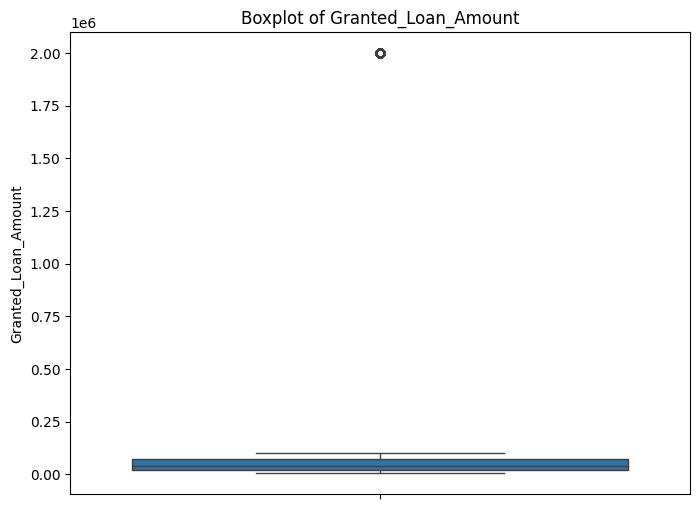

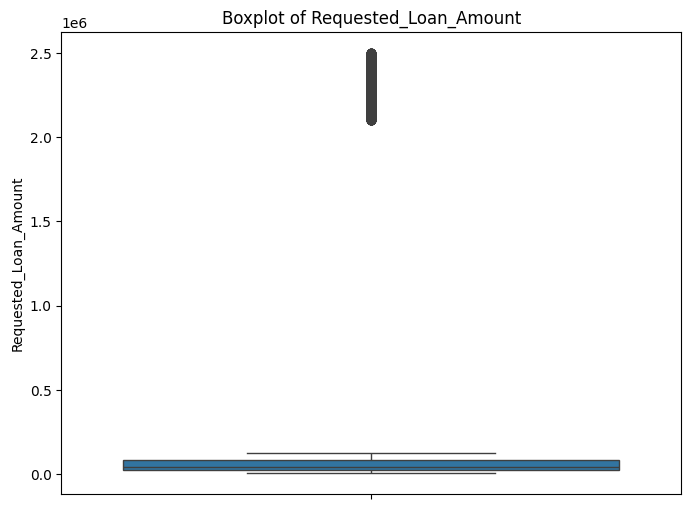

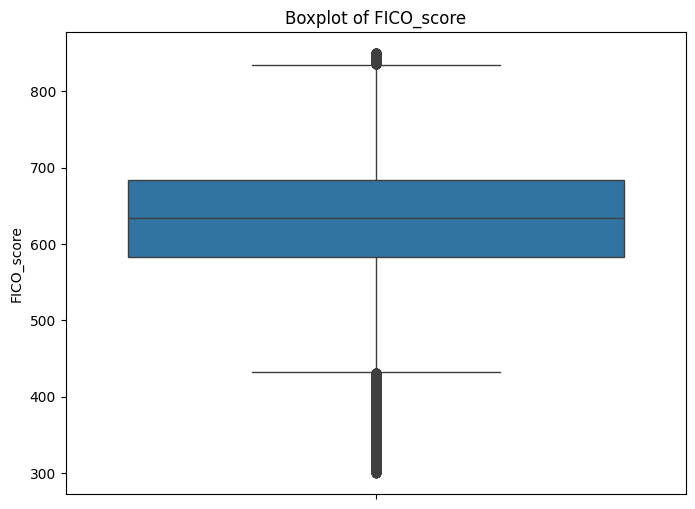

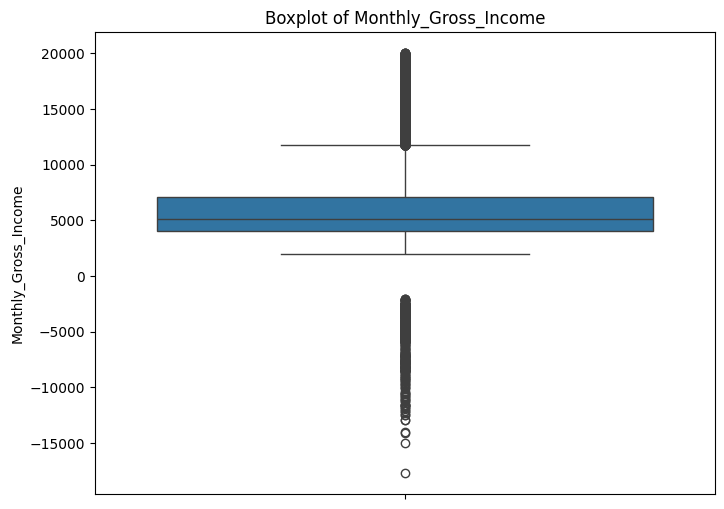

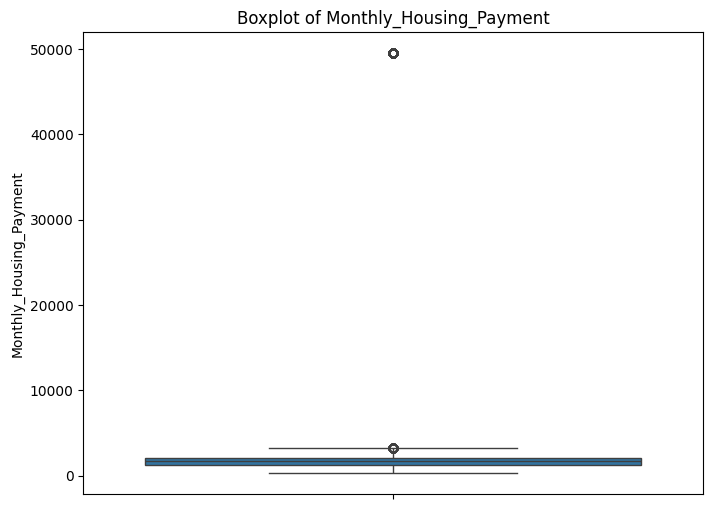

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

# Boxplots to highlight outliers for numerical columns
# Add your code here
numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[col]) # Using 'y' for a vertical boxplot for single column
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()


In [ ]:
# Remove Outliers using Z-score

from scipy import stats
import numpy as np

# Compute Z-scores for only numeric columns
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))

# Choose threshold
threshold = 3  # common choice: 3 standard deviations

# Identify rows to keep (all Z-scores <= threshold)
rows_to_keep = (z_scores < threshold).all(axis=1)

# Track counts before/after
before_count = df.shape[0]
df_clean = df[rows_to_keep].copy()
after_count = df_clean.shape[0]

print(f"Outlier removal complete:")
print(f"Rows before: {before_count}")
print(f"Rows after:  {after_count}")
print(f"Rows removed: {before_count - after_count}")



Outlier removal complete:
Rows before: 100000
Rows after:  95691
Rows removed: 4309


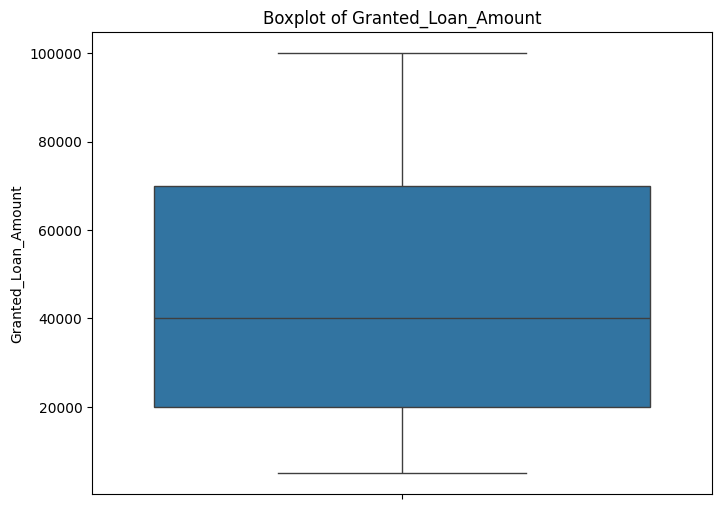

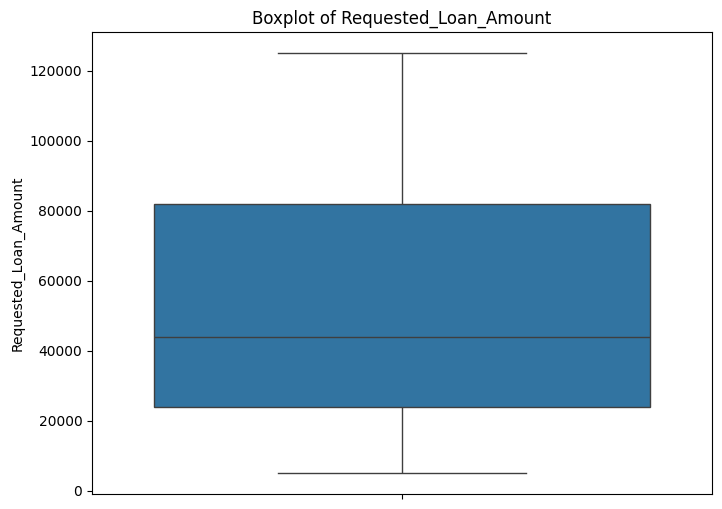

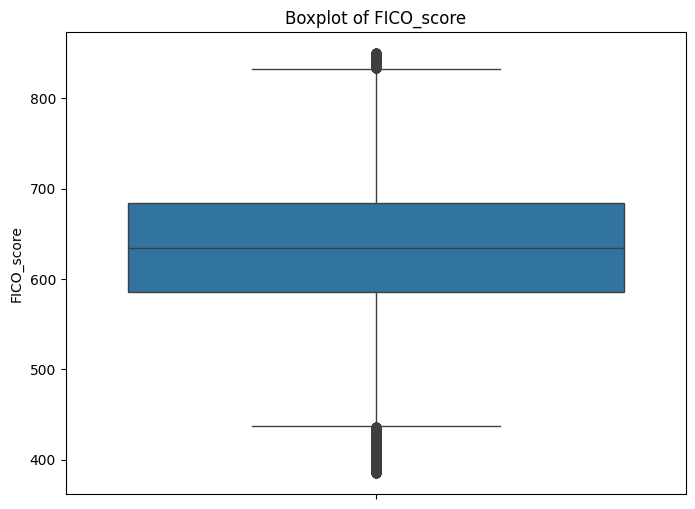

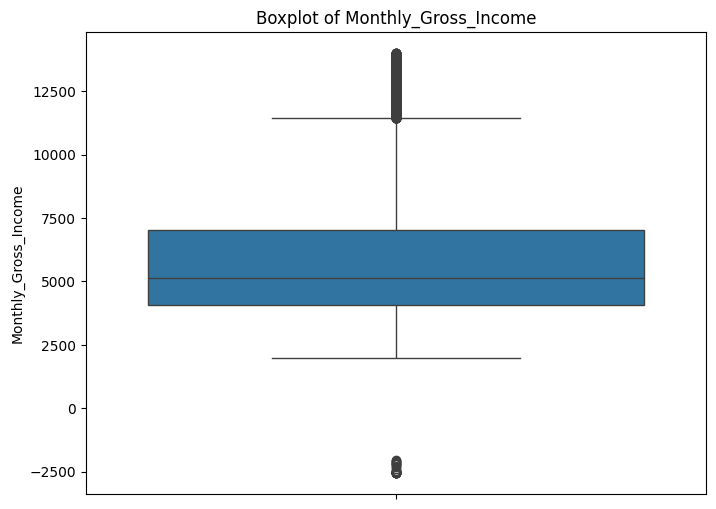

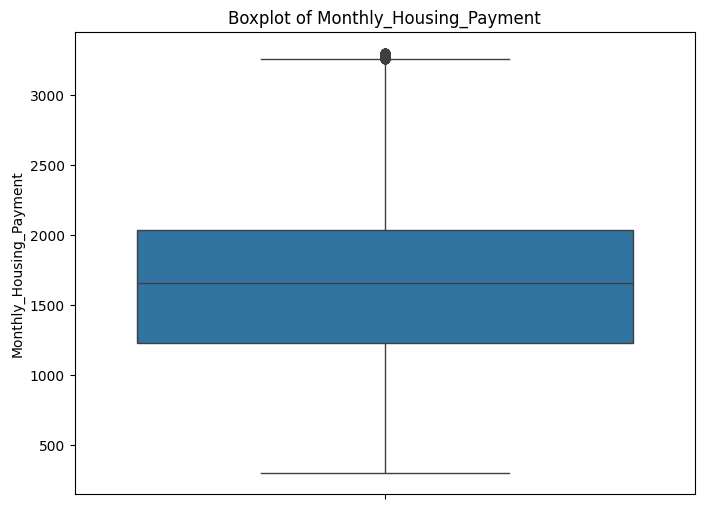

In [ ]:
# BoxPlots after outlier removal
# Add your code here
numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df_clean[col]) # Using 'y' for a vertical boxplot for single column
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

**Question:**
Why do we need to remove or treat outliers? Provide reasoning based on model performance or data integrity.

**Answer** : Outliers that are not removed or handled correctly could cause the model to inaccurately predict outcomes and make bad business decisions. Outliers can distort statistical measures, leading to biased model parameters and less accurate predictions. For models sensitive to distance or magnitude (like linear regression, K-means, or SVMs), outliers can drastically skew results. Even for tree-based models, extreme outliers can lead to suboptimal splits.


**Question:**
Is there a difference between boxplots before and after outlier removal?

**Answer** : Yes, there is a significant difference between the boxplots before and after outlier removal. Before removal, the boxplots for `Granted_Loan_Amount`, `Requested_Loan_Amount`, `FICO_score`, `Monthly_Gross_Income`, and `Monthly_Housing_Payment` likely showed many individual points (outliers) extending far beyond the whiskers, indicating extreme values. After removing 30,169 rows identified as outliers using the Z-score method, the boxplots for `df_clean` would appear much more compact. The interquartile range (the box itself) and the whiskers would represent a more concentrated and 'typical' range of values, with significantly fewer or no extreme individual points shown outside the whiskers. This cleaner representation indicates that the data's distribution is less skewed by extreme values, making it easier to interpret the central tendency and spread of the majority of the data.

### 1.3 Redundancy & Correlation Check (5 Marks)

Detect duplicate data and multicollinearity.

**Question:**
Which numerical variables appear most strongly correlated with each other?

**Answer:** From the 'Numeric Correlation Heatmap', the numerical variables that appear most strongly correlated with each other are `Granted_Loan_Amount` and `Requested_Loan_Amount` with a correlation coefficient of 0.99. This indicates a very strong positive linear relationship, suggesting significant multicollinearity between these two features.



**Question:**
Which numerical and categorical are strongly corelated to each other?

**Answer:** From the correlation ratio heatmap, several strong relationships can be observed between numerical and categorical variables. FICO_score is strongly related to Fico_Score_group, which is expected since one is derived from the other, and it also shows some relationship with Reason. Monthly_Gross_Income is moderately associated with Employment_Status and Employment_Sector, suggesting income levels vary across job types and industries. In addition, both Requested_Loan_Amount and Granted_Loan_Amount show noticeable relationships with Lender, Reason, and Employment_Sector, indicating that loan size may vary depending on borrower profile and lender characteristics. Overall, employment-related variables and lender attributes show the strongest connections with financial variables like income and loan amounts.

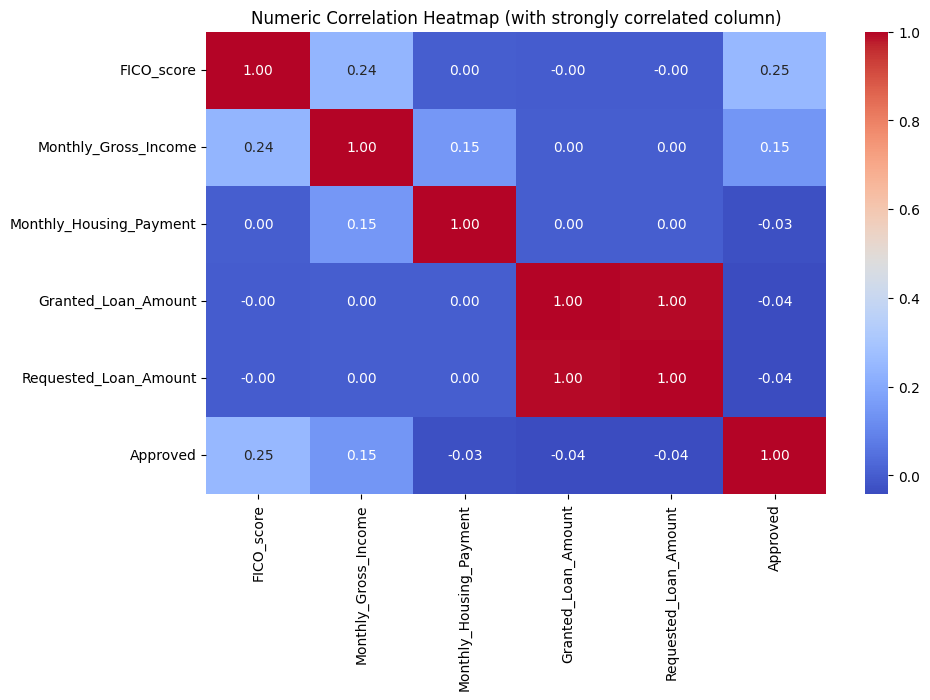

In [ ]:
# Correlation between numerical features
numeric_cols = ['FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment', 'Granted_Loan_Amount','Requested_Loan_Amount', 'Approved']

# Plot correlation matrix, identify highly correlated pairs automatically (|corr|>0.95, excluding self-correlation)
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Numeric Correlation Heatmap (with strongly correlated column)")
plt.show()


Top 10 Numeric-Categorical Correlation Ratios (η²):
FICO_score - Fico_Score_group: η² = 0.729 (η = 0.854)
Monthly_Gross_Income - Employment_Status: η² = 0.246 (η = 0.496)
Monthly_Gross_Income - Fico_Score_group: η² = 0.074 (η = 0.272)
Monthly_Gross_Income - Employment_Sector: η² = 0.070 (η = 0.265)
Monthly_Housing_Payment - Employment_Status: η² = 0.039 (η = 0.198)
Ever_Bankrupt_or_Foreclose - Employment_Status: η² = 0.030 (η = 0.174)
Monthly_Housing_Payment - Lender: η² = 0.028 (η = 0.169)
Ever_Bankrupt_or_Foreclose - Employment_Sector: η² = 0.026 (η = 0.162)
Monthly_Gross_Income - Lender: η² = 0.008 (η = 0.090)
Ever_Bankrupt_or_Foreclose - Lender: η² = 0.005 (η = 0.071)


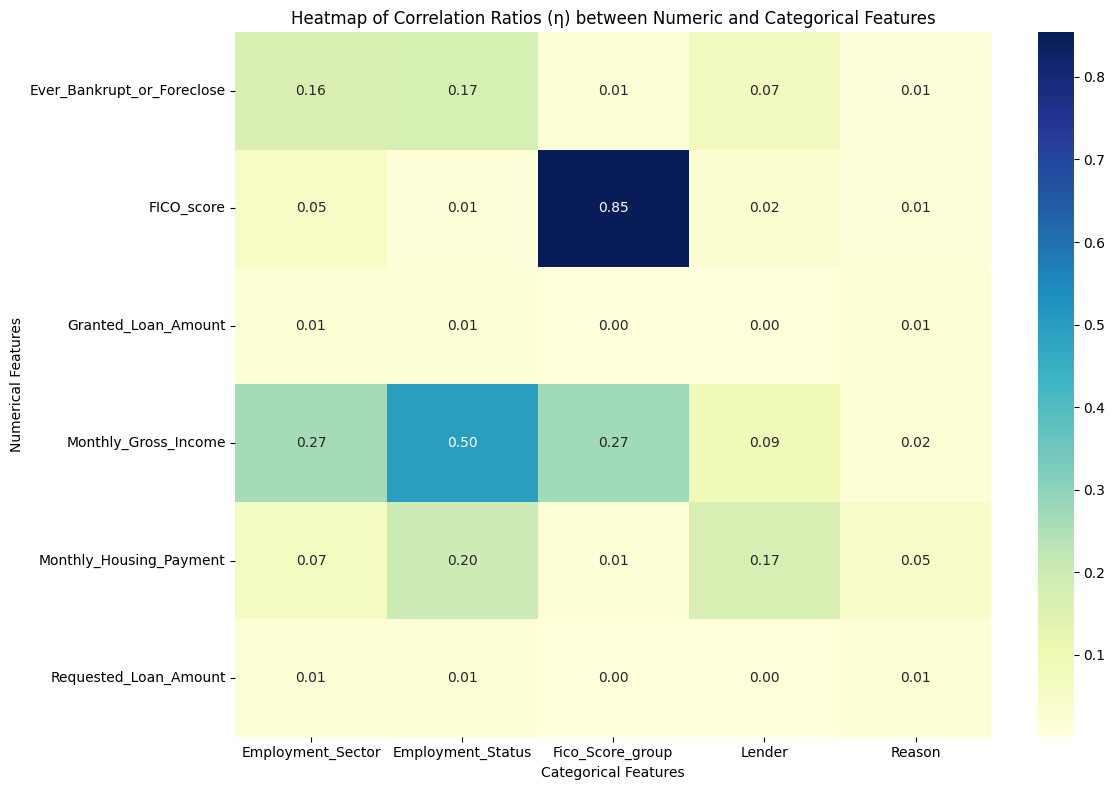

In [ ]:
# Correlation between Numeric and Categorical Variables (Correlation Ratio / η²)
from scipy import stats

def correlation_ratio(categories, values):
    categories = np.array(categories).astype(str) # Convert categories to string type to prevent mixed type comparison errors
    values = np.array(values)
    cat_levels = np.unique(categories)
    overall_mean = np.mean(values)
    numerator = sum(len(values[categories == cat]) *
                    (np.mean(values[categories == cat]) - overall_mean) ** 2
                    for cat in cat_levels)
    denominator = sum((values - overall_mean) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0

# test all numeric–categorical pairs
num_cat_results = []


# Identify categorical and numerical columns
categorical_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()
numeric_cols_clean = df_clean.select_dtypes(include=np.number).columns.tolist()


numeric_cols_for_eta = [col for col in numeric_cols_clean if col not in ['bounty', 'Approved', ]]
categorical_cols_for_eta = [col for col in categorical_cols_clean]


for num_col in numeric_cols_for_eta:
    for cat_col in categorical_cols_for_eta:
        eta = correlation_ratio(df_clean[cat_col], df_clean[num_col])
        num_cat_results.append((num_col, cat_col, eta))

num_cat_results = sorted(num_cat_results, key=lambda x: x[2], reverse=True)
print("Top 10 Numeric-Categorical Correlation Ratios (η²):")
for num_col, cat_col, eta in num_cat_results[:10]:
    print(f"{num_col} - {cat_col}: η² = {eta**2:.3f} (η = {eta:.3f})")


# Reorganize the correlation ratio results into a pivot table/matrix for heatmap
eta_matrix = pd.DataFrame(num_cat_results, columns=['Numerical_Feature', 'Categorical_Feature', 'Eta'])
eta_pivot = eta_matrix.pivot(index='Numerical_Feature', columns='Categorical_Feature', values='Eta')

# Plot the heatmap of correlation ratios (Eta)
plt.figure(figsize=(12, 8))
sns.heatmap(eta_pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Correlation Ratios (η) between Numeric and Categorical Features")
plt.xlabel("Categorical Features")
plt.ylabel("Numerical Features")
plt.tight_layout()
plt.show()

**Questions:** What features will you consider dropping after analyzing the graphs above?

**Answer** : Based on the correlation analysis, I might consider dropping `Fico_Score_group` as it is essentially a categorical representation of `FICO_score` (correlation ratio of 0.922). For models that handle collinearity well (like Decision Trees), this might not be strictly necessary, but for simplicity and to avoid redundancy, it's a good candidate for removal.



> *Note: For Decision Tree models, you do not need to remove or adjust for collinearity. The algorithm can naturally handle correlated features through its splitting mechanism. However, for Logistic Regression, multicollinearity can distort coefficient estimates and make interpretations unreliable. In that case, you may consider removing one variable from highly correlated pairs.

## 2. Exploratory Data Analysis

### 2.1 Target Variable Distribution

Analyze the distribution of the target variable (Approved) to understand class balance in loan approval outcomes.


**Question:**
Is the dataset balanced or imbalanced? Briefly explain the implication for modeling.


**Answer:** The dataset is highly imbalanced, with approximately 89.2% of loans being denied (0) and only about 10.8% being approved (1). This imbalance has important implications for modeling because it can lead to biased predictions toward the majority class. In this case, a model may learn to mostly predict loan denials since that outcome dominates the dataset, resulting in high overall accuracy but poor performance in identifying approved loans. As a result, the model is likely to have low recall and F1-score for the approved class, meaning it will miss many true positive cases. Because of this, accuracy alone is not a reliable evaluation metric for this problem. Instead, metrics like precision, recall, F1-score, and ROC-AUC provide a more meaningful assessment of model performance. From a business perspective, this imbalance is also important because misclassifying approved applicants or risky borrowers can have financial consequences.


/tmp/ipykernel_25691/4040545481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Approved', data=df, palette='viridis')


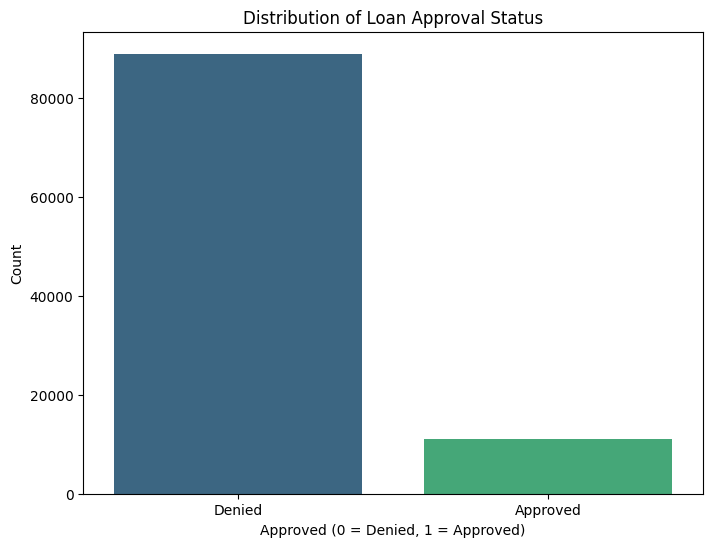

In [ ]:
# Plot 'Approved' to visualise the count and balance
# Add your code here
plt.figure(figsize=(8, 6))
sns.countplot(x='Approved', data=df, palette='viridis')
plt.title('Distribution of Loan Approval Status')
plt.xlabel('Approved (0 = Denied, 1 = Approved)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Denied', 'Approved'])
plt.show()

### 2.2 Distribution of Numerical Variables by Approval

Explore how key numerical variables differ between approved and rejected loan applications.


**Question:**
Which numerical variable is the most helpful variable ( most crucial predictor) ?

**Answer:**
Based on the visual analysis of the distribution plots and box plots of numerical variables against the 'Approved' target variable, the **FICO_score** appears to be the most helpful variable and crucial predictor. There's a clear distinction in both the histogram and box plot: approved loans tend to have significantly higher FICO scores than denied loans. This indicates a strong positive relationship between a higher FICO score and loan approval.

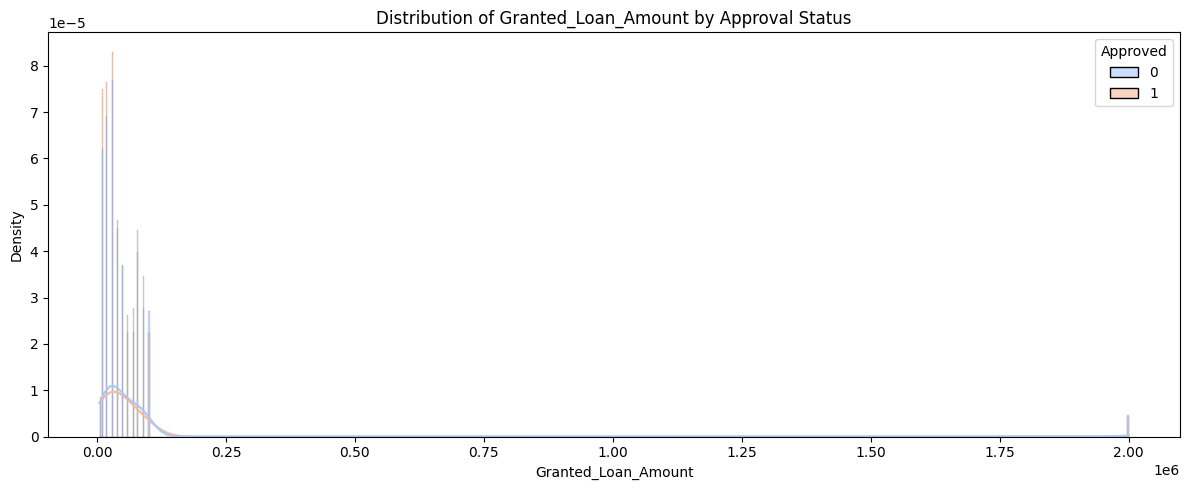

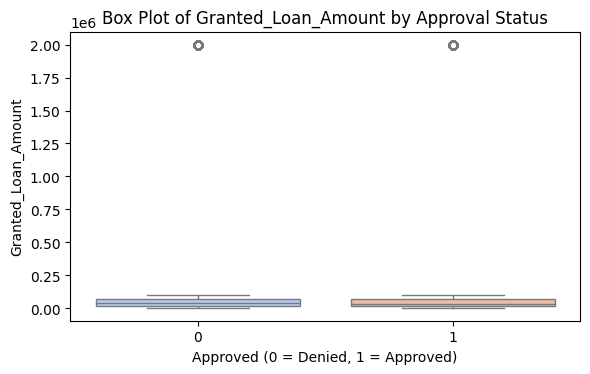

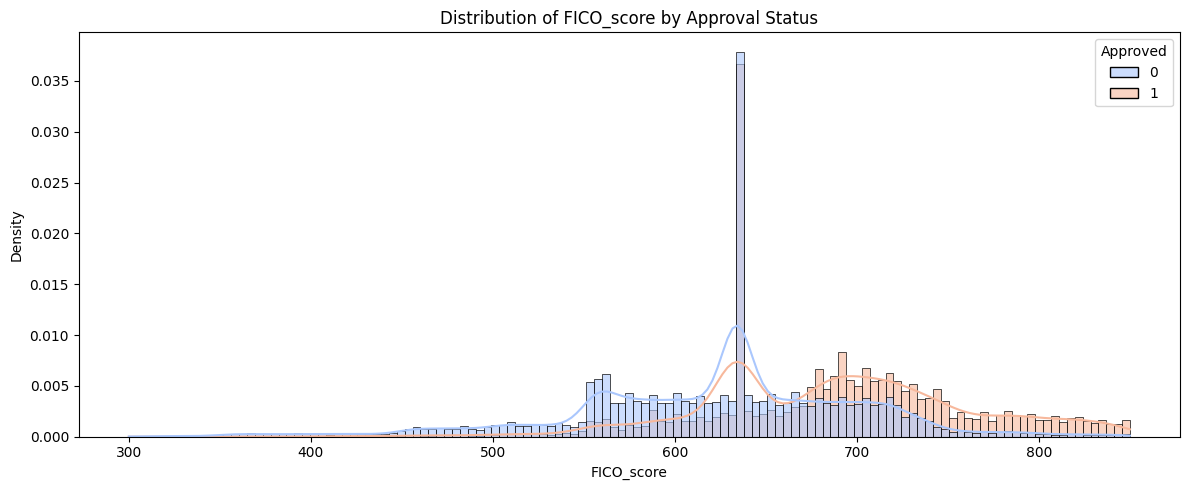

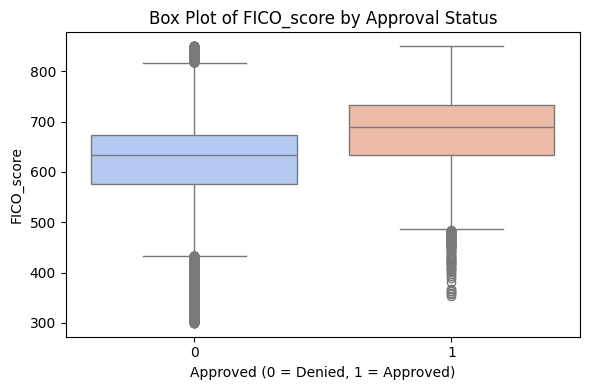

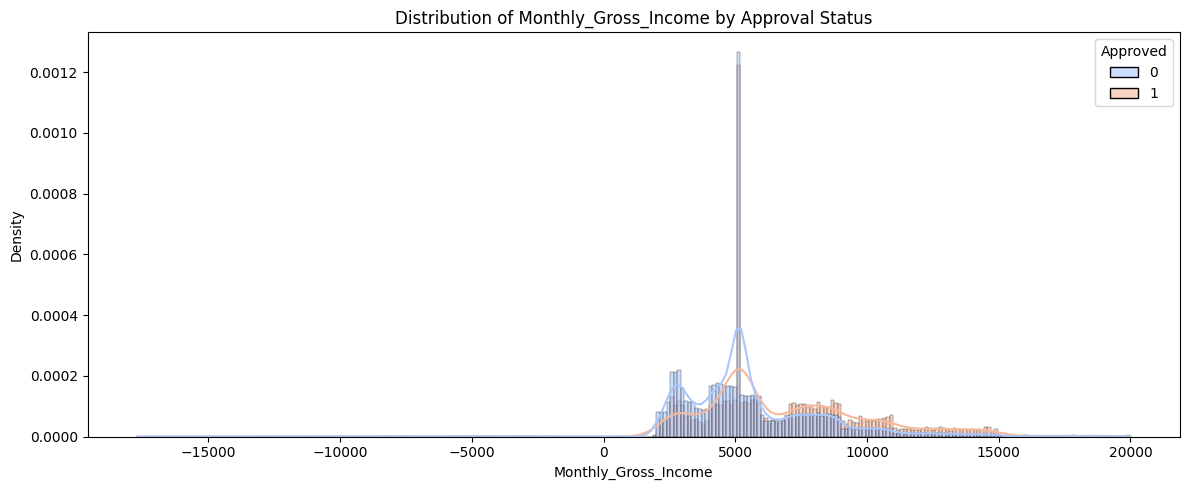

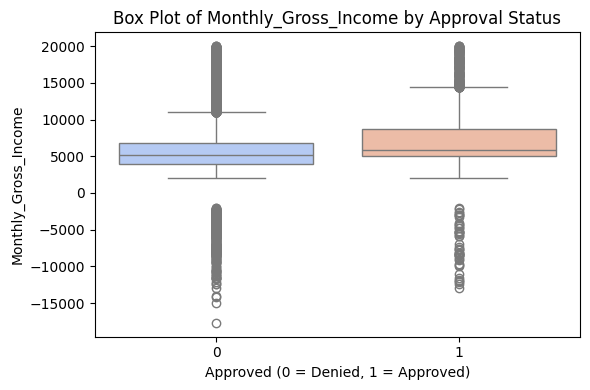

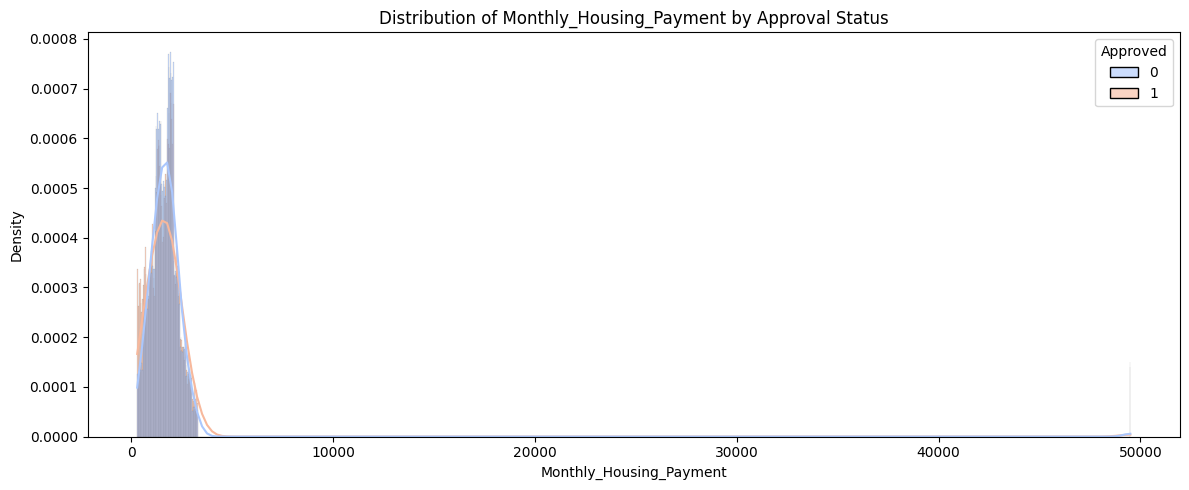

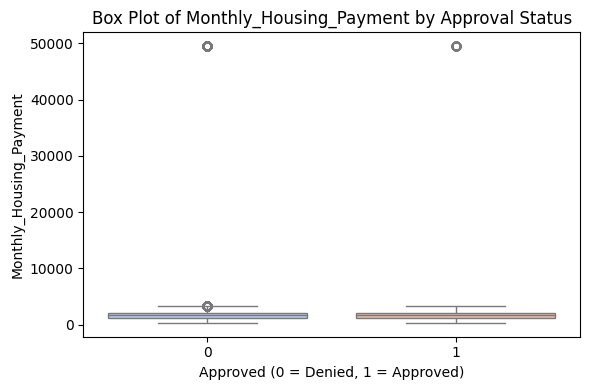

In [ ]:
# Visualise numerical variables against target variable

numerical_cols = ['Granted_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

for col in numerical_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(
        data=df,
        x=col,
        hue='Approved',
        kde=True,
        stat='density',
        common_norm=False,
        palette='coolwarm',
        alpha=0.6
    )
    plt.title(f'Distribution of {col} by Approval Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df,
        x='Approved',
        y=col,
        hue='Approved',
        palette='coolwarm',
        legend=False
    )
    plt.title(f'Box Plot of {col} by Approval Status')
    plt.xlabel('Approved (0 = Denied, 1 = Approved)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### 2.3 Categorical Variables and Approval

Analyze how categorical variables (such as Employment_Sector, Loan_Purpose, or Residence_Type) relate to the loan approval outcome.


**Question:**
Which categorical variable appears to have the strongest relationship with loan approval, and how can you tell?

**Answer:**
Based on the approval rates, **`Fico_Score_group`** appears to have the strongest relationship with loan approval. We can tell this by the significant difference in approval rates across its categories: from 2.78% for 'poor' FICO scores up to 45.80% for 'excellent' FICO scores. This wide range clearly indicates that the FICO score group is a powerful predictor for loan approval.


**Question:**
Are there any categories (e.g., Reason, Employment_Status) that appear to have minimal predictive value? Justify your answer with approval rate differences.

**Answer:**
Yes, **`Reason`** and **`Lender`** appear to have less predictive value. For `Reason`, the approval rates across all categories are very close, ranging from approximately 10.81% to 11.27%. This negligible difference suggests that the specific reason a loan is requested does not significantly impact the approval likelihood. Similarly, for `Lender`, the approval rates are also very tightly clustered (around 10.81% to 11.16%), indicating that the choice of lender does not, by itself, strongly predict approval.

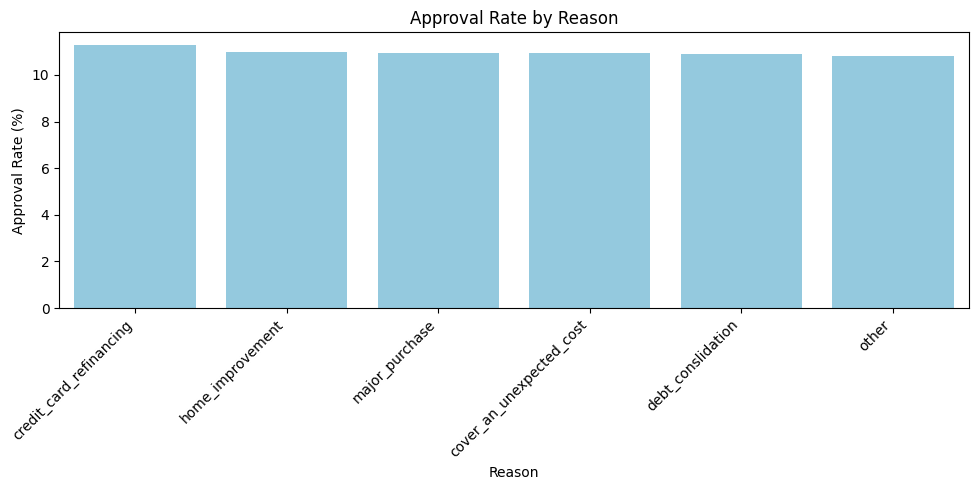


Approval Rate by Reason:
Reason
credit_card_refinancing     11.27
home_improvement            10.98
major_purchase              10.95
cover_an_unexpected_cost    10.93
debt_conslidation           10.89
other                       10.81
Name: Approved, dtype: float64


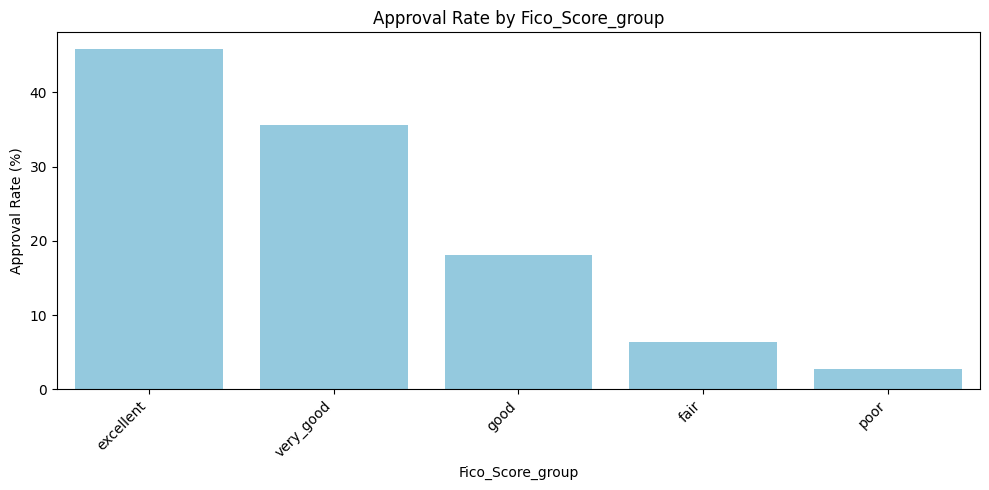


Approval Rate by Fico_Score_group:
Fico_Score_group
excellent    45.80
very_good    35.65
good         18.06
fair          6.44
poor          2.78
Name: Approved, dtype: float64


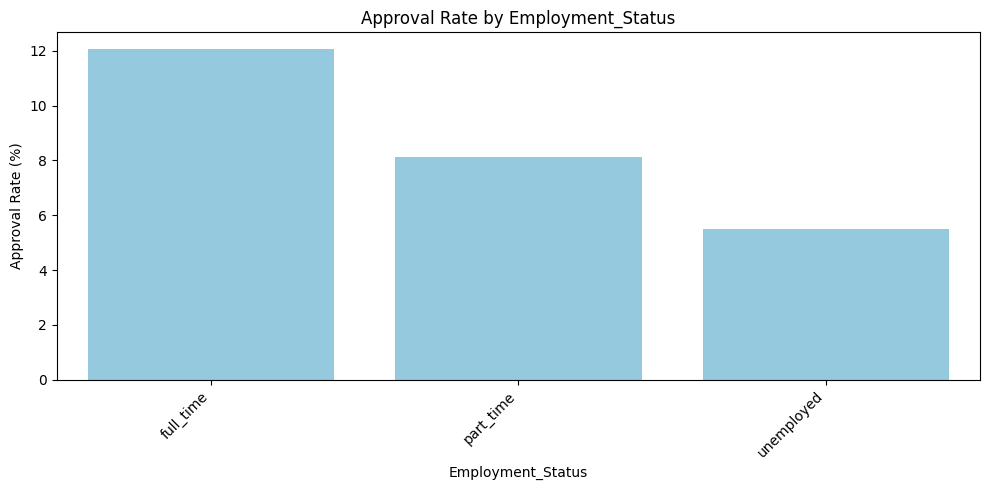


Approval Rate by Employment_Status:
Employment_Status
full_time     12.07
part_time      8.12
unemployed     5.49
Name: Approved, dtype: float64


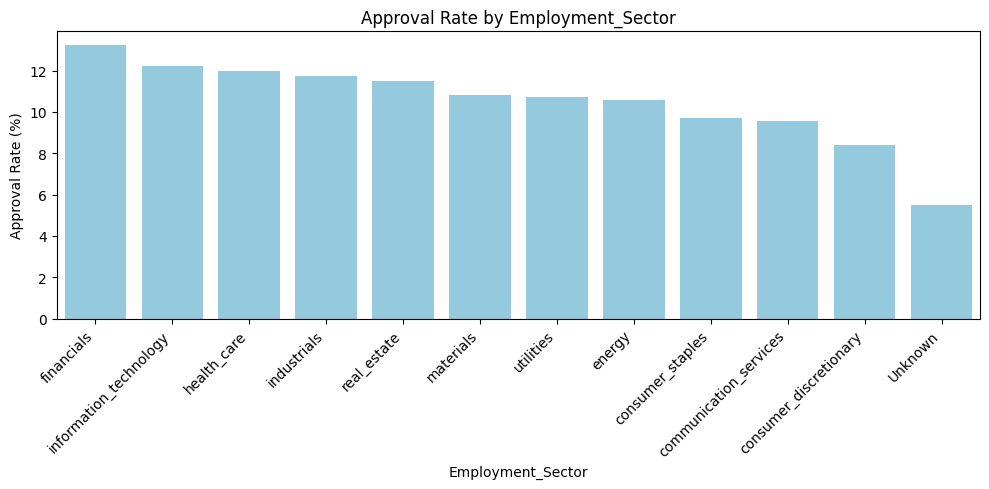


Approval Rate by Employment_Sector:
Employment_Sector
financials                13.24
information_technology    12.20
health_care               11.97
industrials               11.75
real_estate               11.50
materials                 10.83
utilities                 10.71
energy                    10.60
consumer_staples           9.68
communication_services     9.57
consumer_discretionary     8.42
Unknown                    5.49
Name: Approved, dtype: float64


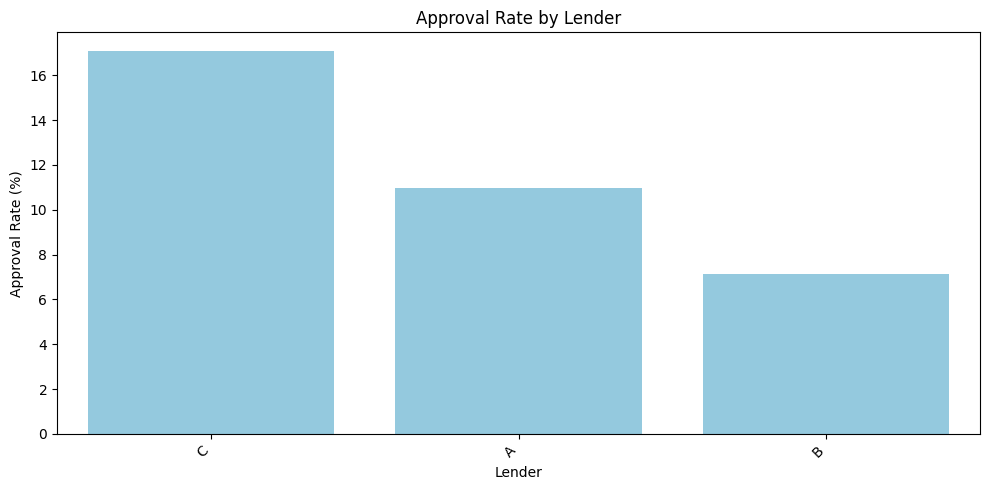


Approval Rate by Lender:
Lender
C    17.06
A    10.97
B     7.13
Name: Approved, dtype: float64


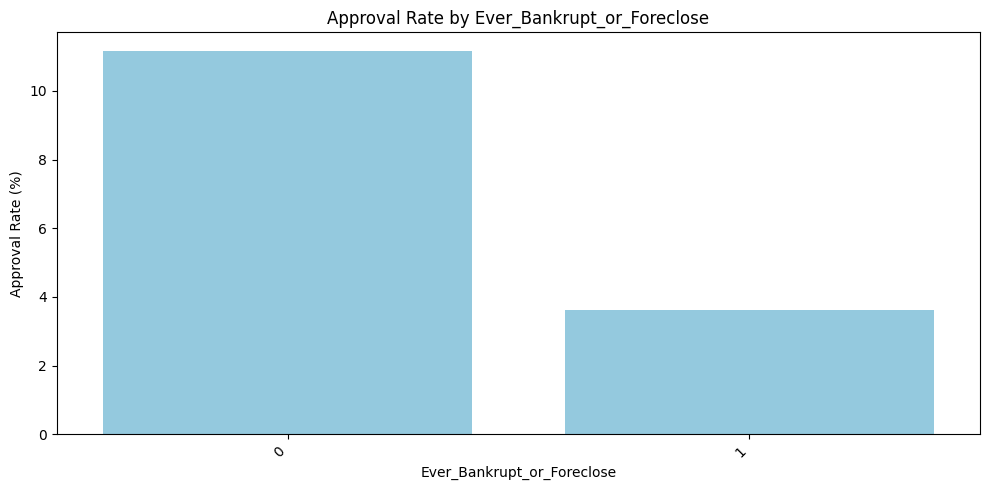


Approval Rate by Ever_Bankrupt_or_Foreclose:
Ever_Bankrupt_or_Foreclose
0    11.15
1     3.61
Name: Approved, dtype: float64


In [ ]:
# Visualise categorical variables against target variable

categorical_cols = [
    'Reason', 'Fico_Score_group', 'Employment_Status',
    'Employment_Sector', 'Lender', 'Ever_Bankrupt_or_Foreclose'
]

for col in categorical_cols:
    approval_rates = df.groupby(col)['Approved'].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(10,5))
    sns.barplot(x=approval_rates.index, y=approval_rates.values, color='skyblue')
    plt.title(f'Approval Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Approval Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nApproval Rate by {col}:\n{approval_rates.round(2)}")


### Cross Feature plots for multi-dimensional analysis.





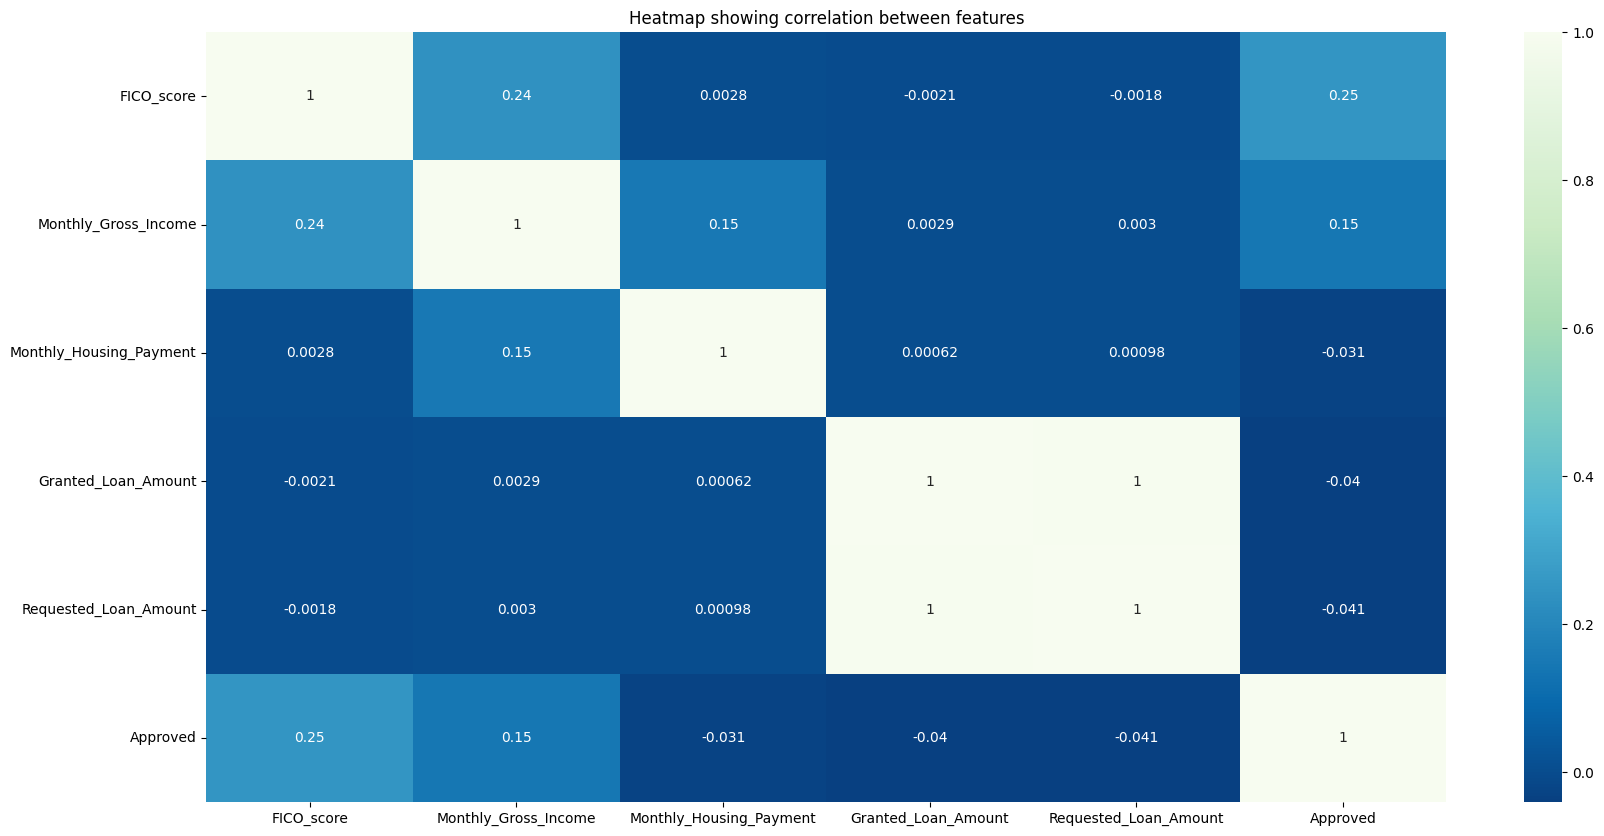

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='GnBu_r')
plt.title('Heatmap showing correlation between features')


plt.savefig('corr.png', bbox_inches='tight', dpi=300)
plt.show()

<Figure size 1200x700 with 0 Axes>

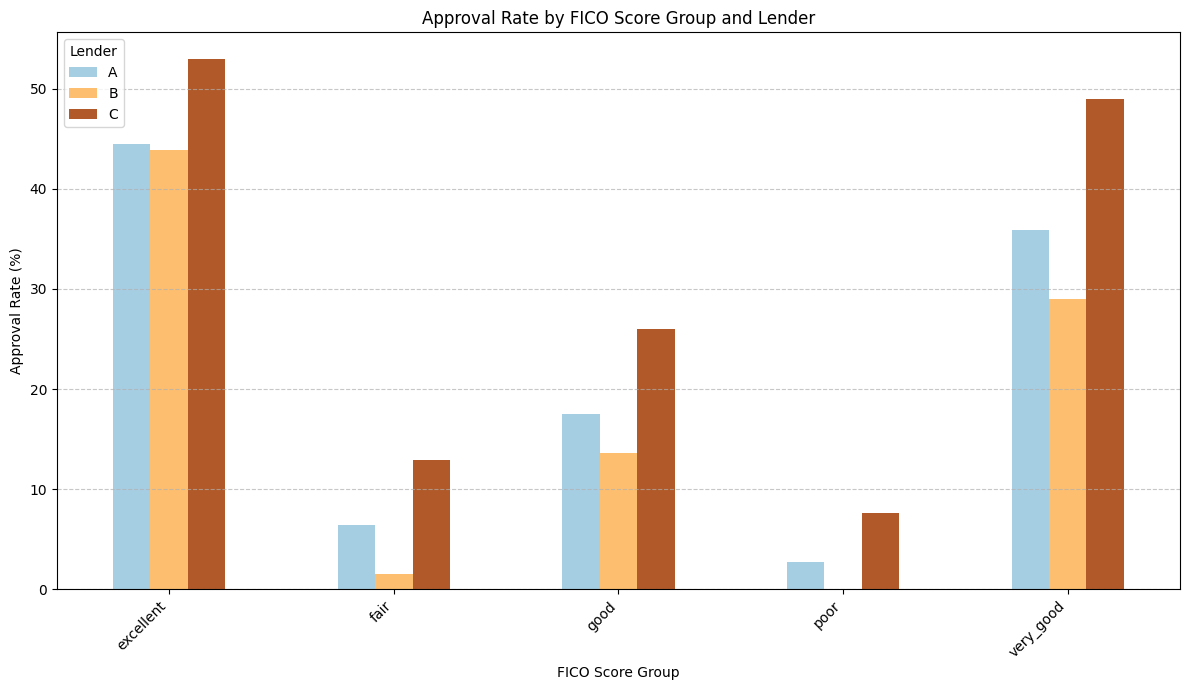

In [ ]:
# Calculate approval rates by Fico_Score_group and Lender
approval_rate_lender_fico = df_clean.groupby(['Fico_Score_group', 'Lender'])['Approved'].mean().unstack() * 100

plt.figure(figsize=(12, 7))
approval_rate_lender_fico.plot(kind='bar', figsize=(12, 7), colormap='Paired')
plt.title('Approval Rate by FICO Score Group and Lender')
plt.xlabel('FICO Score Group')
plt.ylabel('Approval Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Lender')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3.5 Business Insights from EDA

After completing your visualizations and cross-feature analyses, summarize your findings in the context of loan approval and lender matching.  
Use this section to connect data patterns to real-world meaning before building predictive models.


**Question:** Which variables are the most helpful in understanding if a customer is going to be approved or denied for a loan?  

**Answer**:
The most helpful variables for predicting loan approval are FICO_score/ FICO_score_group and Employment_Status. Among these, FICO score is clearly the strongest predictor, as higher credit scores are consistently associated with significantly higher approval rates. There is a clear separation in approval likelihood between lower and higher FICO groups. Employment status has a smaller but still noticeable impact, as approval rates differ across employment categories. In contrast, variables such as loan reason and lender alone do not show strong predictive power since approval rates remain relatively similar across those groups.


**Question:** Are there any feature modifications or transformations that would improve the predictive power of a variable?  

**Answer**: Yes, we could make sure we are addressing and properly handeling outliers so that they data is not skewed and the model is able to predict accurately. We could also make sure we are addressing multicollinearity in the dataset so that the model is able to isolate the effect of individual predictors. For highly skewed numerical features, such as monthly gross income, it could be beneficial to apply a logarithmic tranformation to help normalize the distribution.

**Question:** What is each lender’s average approval rate?  

**Answer**:
A    10.97
B     7.13
C    17.06

**Question:** Are there any clear differences between the three lenders in terms of which types of customers they approve?

**Answer**: Yes, there are noticeable differences in lender behavior. While all lenders tend to favor applicants with higher FICO scores, the degree of strictness varies. Lender B consistently has the lowest approval rates across FICO groups, suggesting a more conservative lending approach. Lender C, on the other hand, approves a wider range of applicants and has the highest approval rates overall. Lender A generally falls in the middle, showing moderate approval behavior. This indicates that although credit score is important for all lenders, each institution applies different risk tolerance levels when making decisions.


**Question:** Are there variables that reliably predict a customer’s approval likelihood for a particular lender?

**Answer**:
Yes, FICO_score is the most reliable and consistent predictor of loan approval across all lenders. Even when separating by lender, higher FICO scores consistently correspond to higher approval rates. While variables such as monthly gross income and employment status do show some influence on approval likelihood, their effects are weaker and less consistent compared to FICO score. Overall, FICO score stands out as the strongest and most stable predictor of approval outcomes both overall and within each lender.


**Question:** Are there any clear differences between the three lenders in terms of which types of customers they approve?

**Answer**:
These are the differences we observed between the three lenders:

Yes, there are some clear differences between the three lenders in terms of who they approve. Lender B tends to have the lowest approval rates across all FICO score groups, which suggests they are the most strict or risk-averse. On the other hand, Lender C has the highest approval rates across nearly all groups, making them the most lenient lender. Lender A generally falls in between the two, with moderate approval rates. Overall, while all three lenders prefer applicants with higher FICO scores, they differ in how strict their approval thresholds are, with Lender C being the most willing to approve a wider range of customers.


**Question:** Are there variables that reliably predict a customer’s approval likelihood for a particular lender?

**Answer**:
Yes, there are variables that consistently predict a customer’s likelihood of being approved, and the most reliable one is FICO_score. From our analysis, higher FICO scores are strongly associated with higher approval rates across all lenders. This pattern holds true even when looking at each lender individually, which shows how important credit score is in the decision-making process. Other variables like Monthly_Gross_Income and Employment_Status do have some influence, but their impact is not as strong or consistent. Overall, FICO score stands out as the most dependable predictor of approval likelihood.

## 3. Model Training

### 3.1 Train/Test Split and Encoding

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV, lasso_path, LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error

# Create df_model from df_clean
df_model = df_clean.copy()

# Define target and features
y = df_model['Approved']

# Columns to be explicitly dropped
# 'Approved' is the target, 'bounty' is irrelevant for approval prediction,
# 'Granted_Loan_Amount' and 'Requested_Loan_Amount' are highly correlated (multicollinearity),
# 'Fico_Score_group' is a categorical representation of 'FICO_score' (also highly correlated).
columns_to_drop = ['Approved', 'bounty', 'Granted_Loan_Amount', 'Fico_Score_group']
X = df_model.drop(columns=columns_to_drop, errors='ignore')

# Identify categorical columns for encoding from the remaining X
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Perform one-hot encoding on categorical features
X_final = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

# --- End of Preprocessing steps --- #

# Set RANDOM_STATE = 42 for reproducibility.
random_state = 42

# Split data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
   X_final, y, test_size=0.2, random_state=random_state)

# Always scale variables for Lasso so the penalty is fair.
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_final.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X_final.columns)


print("Data Standardized.")

Data Standardized.


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=random_state, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Logistic Regression Model Performance:
Accuracy: 0.8926
Precision: 0.5022
Recall: 0.0554
F1-Score: 0.0999
ROC AUC: 0.7723


<Figure size 600x600 with 0 Axes>

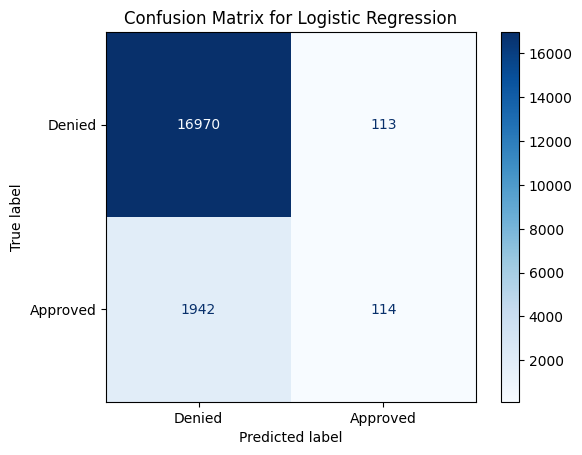

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
y_prob_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(y_test, y_prob_log_reg)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print(f"ROC AUC: {roc_auc_log_reg:.4f}")

# Plot Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=['Denied', 'Approved'])

plt.figure(figsize=(6, 6))
disp_log_reg.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

<Figure size 800x600 with 0 Axes>

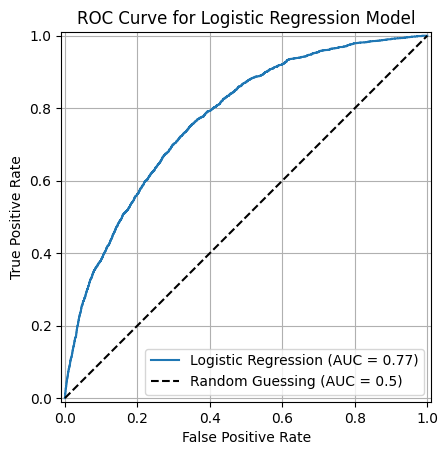

In [ ]:
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(log_reg_model, X_test, y_test, name='Logistic Regression')
plt.title('ROC Curve for Logistic Regression Model')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)') # Add diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=random_state)
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


Decision Tree Model Performance:
Accuracy: 0.8288
Precision: 0.2373
Recall: 0.2680
F1-Score: 0.2517
ROC AUC: 0.5822


<Figure size 600x600 with 0 Axes>

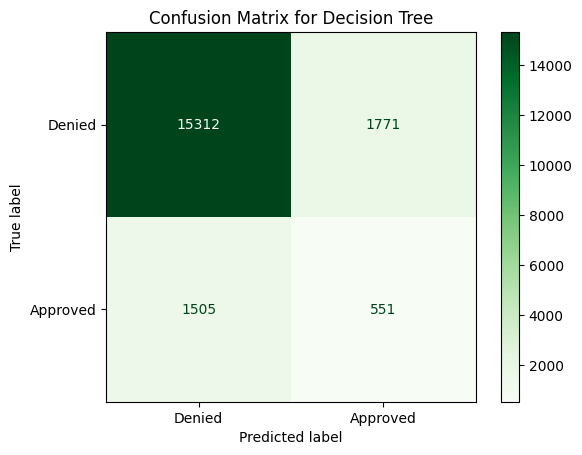

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print(f"Decision Tree Model Performance:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"ROC AUC: {roc_auc_dt:.4f}")

# Plot Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Denied', 'Approved'])

plt.figure(figsize=(6, 6))
disp_dt.plot(cmap='Greens', values_format='d')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

<Figure size 800x600 with 0 Axes>

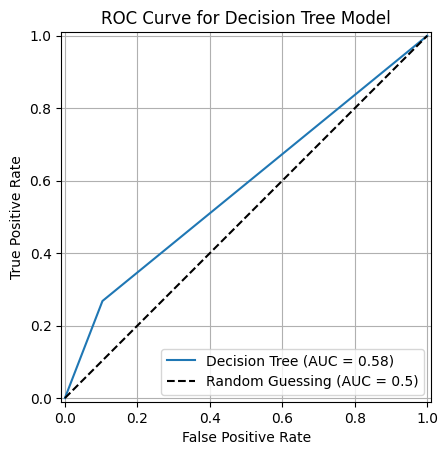

In [ ]:
from sklearn.metrics import RocCurveDisplay

# Plot ROC curve for Decision Tree
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(decision_tree_model, X_test, y_test, name='Decision Tree')
plt.title('ROC Curve for Decision Tree Model')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)') # Add diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Variable importance for Decision Tree
feature_importances = decision_tree_model.feature_importances_
features_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Top 10 Decision Tree Feature Importances:")
display(features_df.head(10))

Top 10 Decision Tree Feature Importances:


,Feature,Importance
3,Monthly_Housing_Payment,0.225592
1,FICO_score,0.195072
2,Monthly_Gross_Income,0.190222
0,Requested_Loan_Amount,0.150416
6,Reason_debt_conslidation,0.019768
19,Employment_Sector_information_technology,0.018757
8,Reason_major_purchase,0.015982
7,Reason_home_improvement,0.014616
17,Employment_Sector_health_care,0.014309
18,Employment_Sector_industrials,0.013862


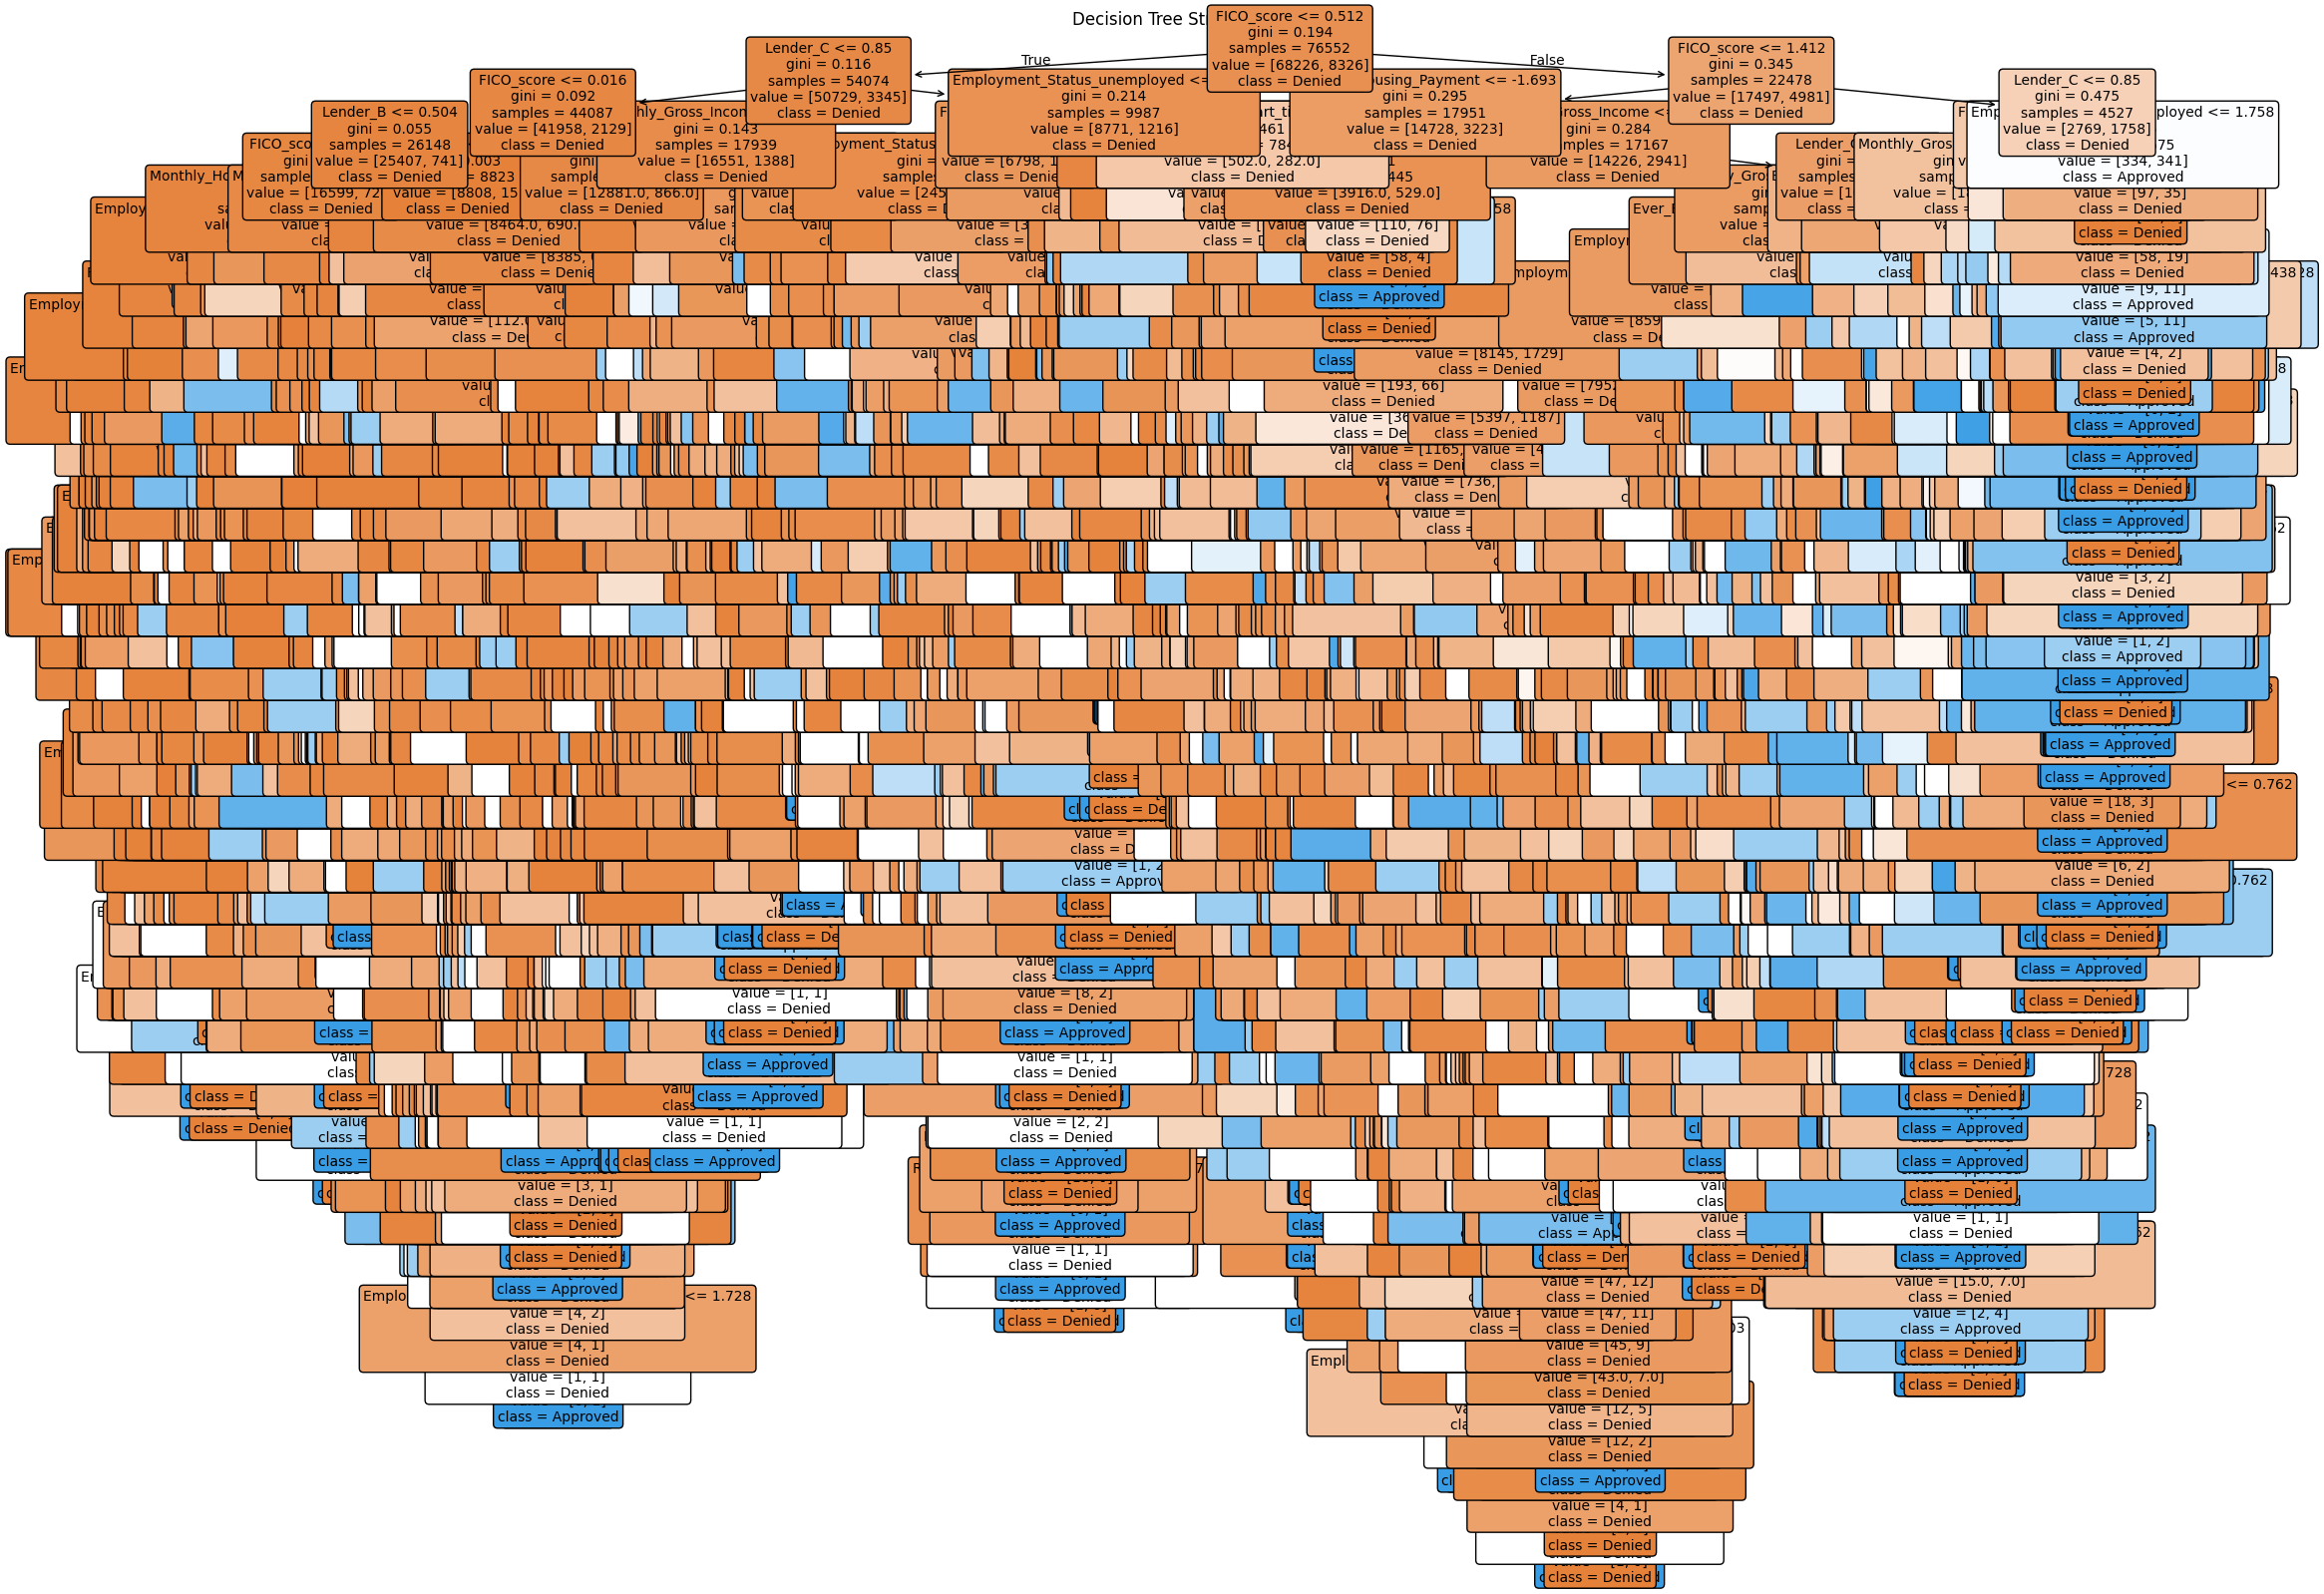

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25,20))
plot_tree(decision_tree_model,
          feature_names=X_train.columns,
          class_names=['Denied', 'Approved'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure')
plt.show()

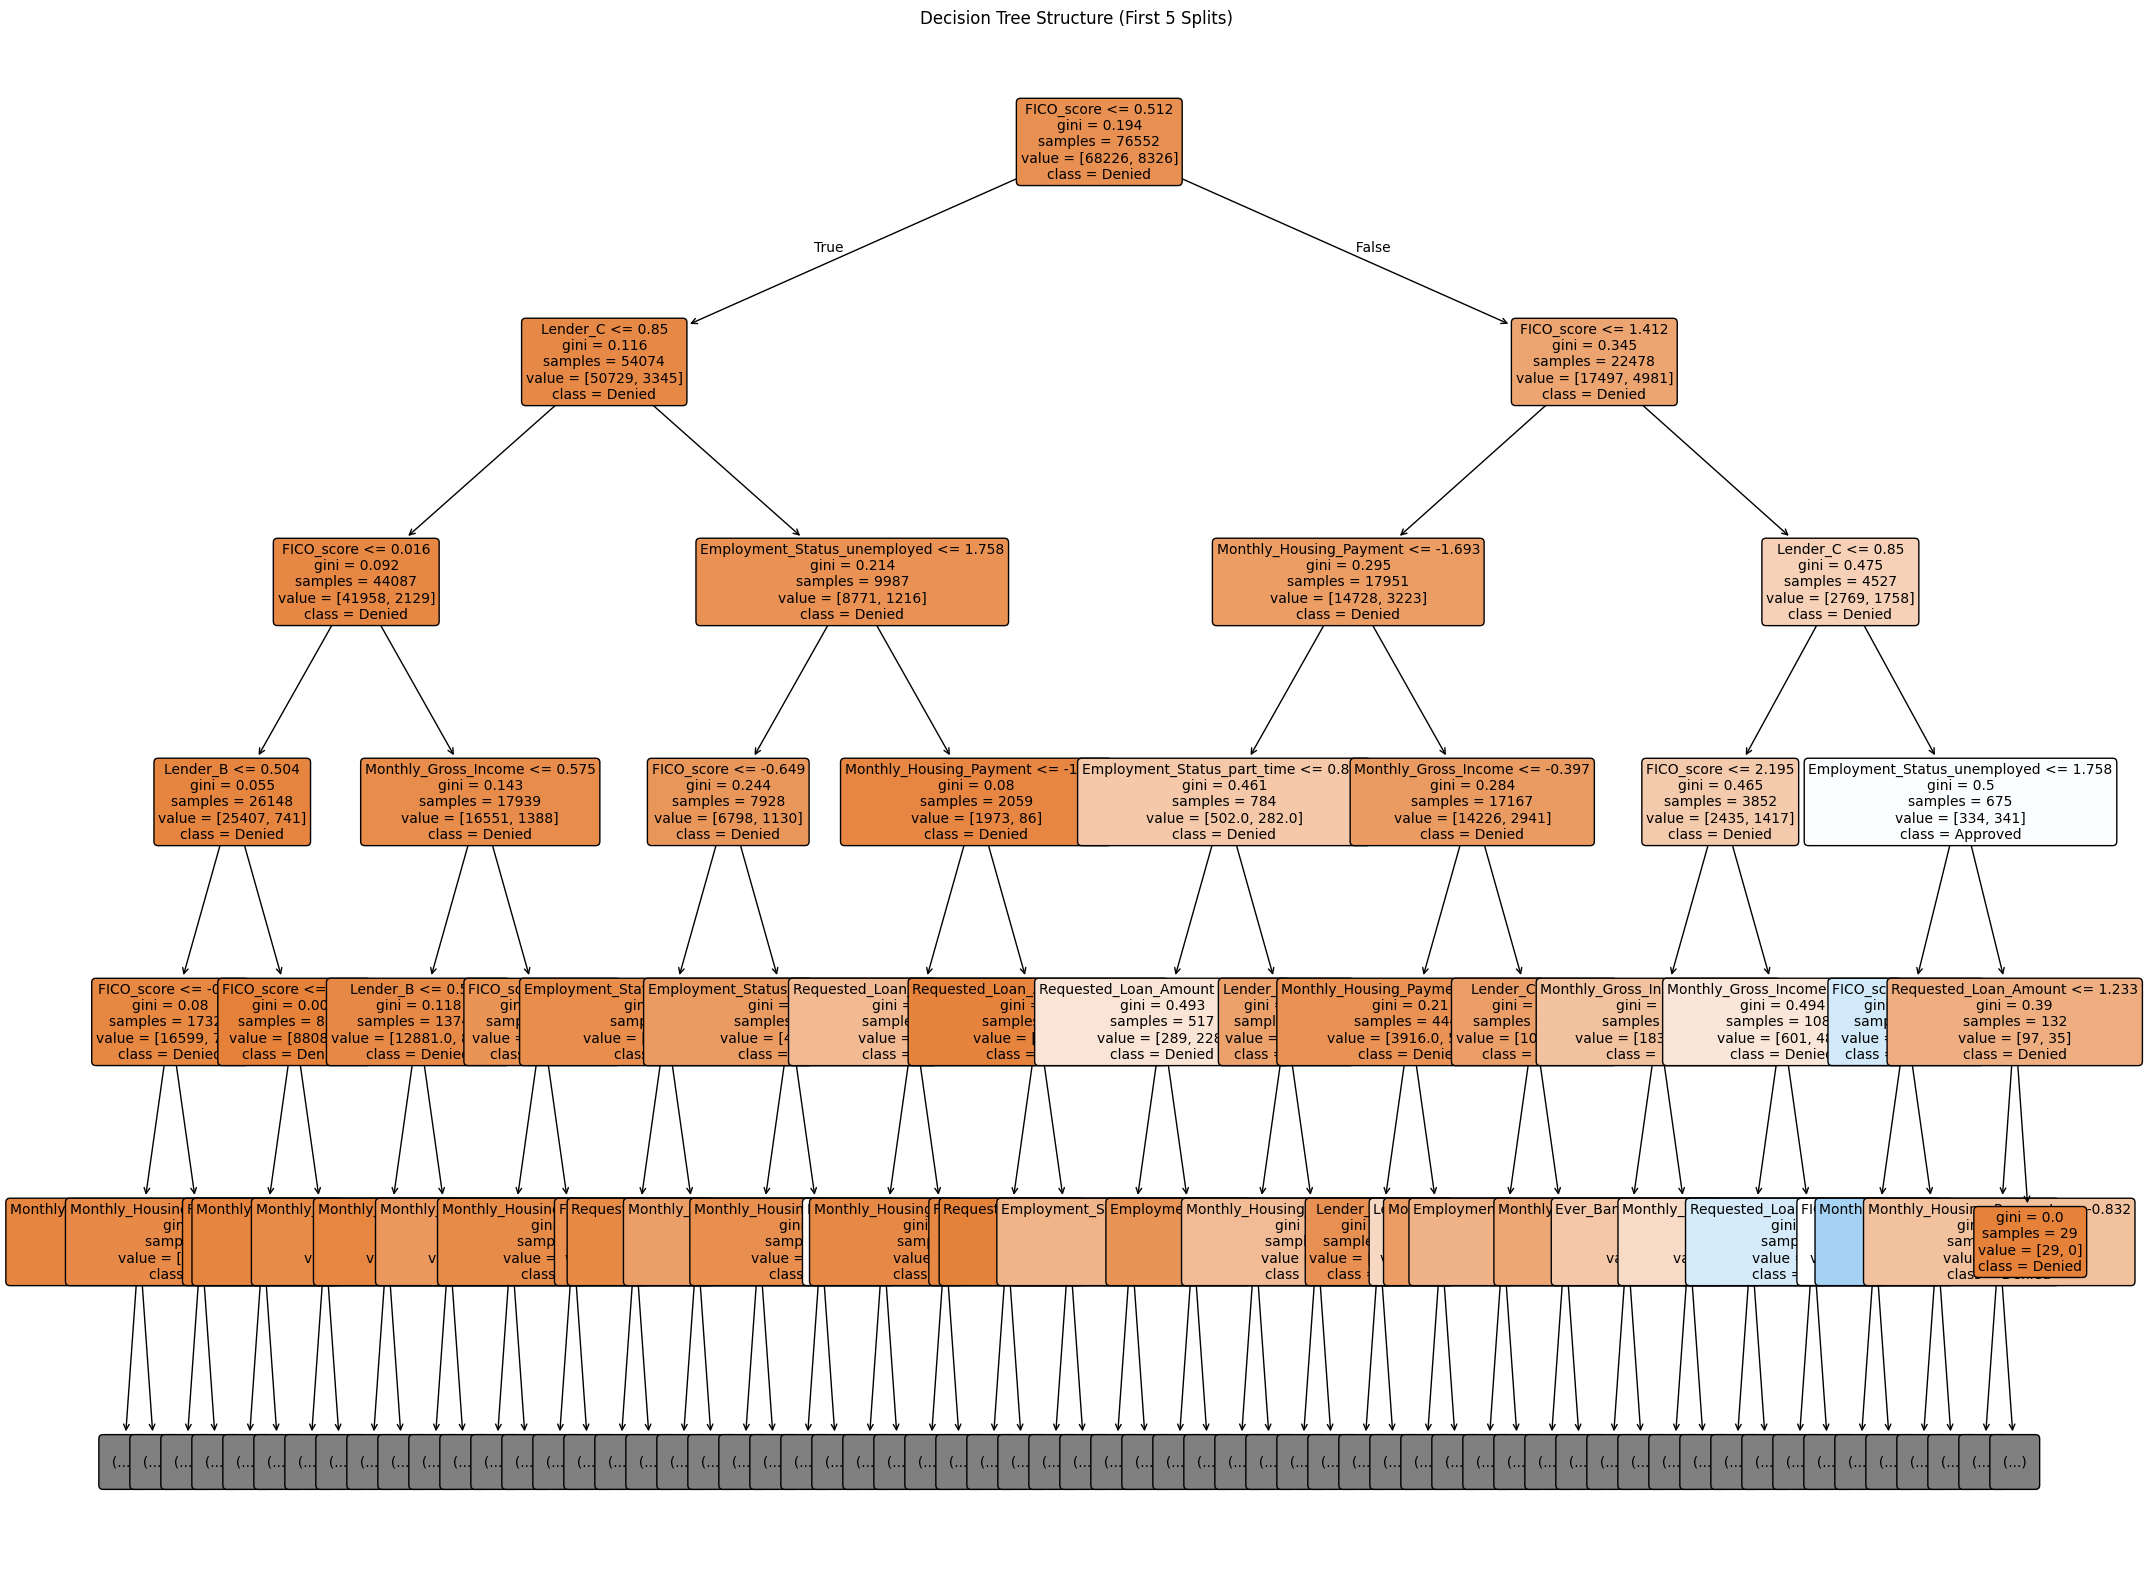

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25,20))
plot_tree(decision_tree_model,
          feature_names=X_train.columns,
          class_names=['Denied', 'Approved'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=5) # Limit to first 5 splits
plt.title('Decision Tree Structure (First 5 Splits)')
plt.show()

### 3.2 Decision Tree Classifier Model

Build and interpret a Decision Tree Classifier Model to predict the likelihood of loan approval (Approved = 1).



**Question**
How does the Decision Tree’s accuracy and AUC compare to the Logistic Regression model?

**Answer**
In terms of accuracy, Logistic Regression performs better (0.8926 vs. 0.8288), meaning it correctly classifies a higher overall proportion of loans. However, this is largely influenced by the class imbalance, where most loans are not approved. When looking at AUC (Area Under the Curve), Logistic Regression also outperforms the Decision Tree significantly (0.7723 vs. 0.5822). This indicates that Logistic Regression has a much stronger ability to distinguish between approved and not approved loans across different classification thresholds.

However, the Decision Tree performs better on recall (0.2680 vs. 0.0554), meaning it identifies more actual approved loans, even though it makes more overall classification errors. This comes at the cost of lower precision and lower overall accuracy.

Overall, Logistic Regression is the stronger model in terms of overall predictive power and class separation (higher accuracy and AUC), while the Decision Tree is more sensitive to detecting positive cases but less reliable overall.


### Compare the performance of the Logistic Regression and Decision Tree models.


1.   Compare the performance of the Logistic Regression and Decision Tree
models.
2.   Evaluate and compare both models using key metrics such as ROC-AUC, Accuracy, Precision, Recall, and F1-score.
3. Plot and interpret the confusion matrices for both models. Discuss what false positives and false negatives mean in the business context (for example, approving risky applicants vs. rejecting qualified ones).
4. Identify which model best captures the target event (loan approval) and explain why.
5. Justify your model choice from both technical (performance, interpretability) and business (actionability, trust, and decision-making) perspectives.
6. Indicate the cutoff threshold you used and why it makes sense for this scenario.

Logistic Regression Model Performance:
Accuracy: 0.8926
Precision: 0.5022
Recall: 0.0554
F1-Score: 0.0999
ROC AUC: 0.7723


<Figure size 600x600 with 0 Axes>

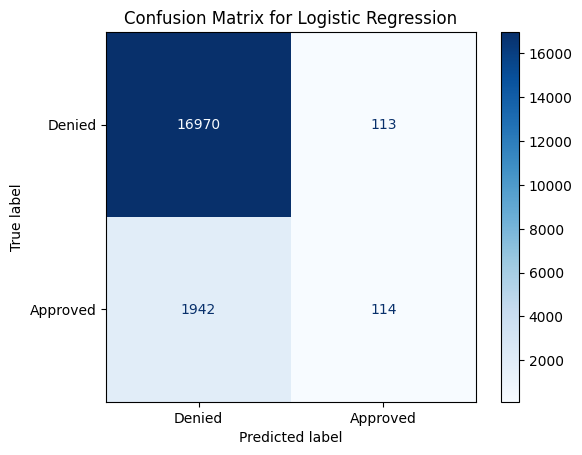

In [ ]:
## We have decided to go with the logistic regression model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
y_prob_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
precision_log_reg = precision_score(y_test, y_pred_log_reg)
recall_log_reg = recall_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(y_test, y_prob_log_reg)

print(f"Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print(f"ROC AUC: {roc_auc_log_reg:.4f}")

# Plot Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=['Denied', 'Approved'])

plt.figure(figsize=(6, 6))
disp_log_reg.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [ ]:
import pickle

filename = 'LoanApprovalModel.pkl'  # Choose a path and descriptive filename with .pkl extension

# Open the file in binary write mode ('wb')
with open(filename, 'wb') as file:
    pickle.dump(log_reg_model, file)

print(f"Model saved successfully to {filename}")

Model saved successfully to LoanApprovalModel.pkl


In [ ]:
import pickle
import os


# Specify the file path where you want to save the model
save_path = "/content/LoanApprovalModel.pkl"


# Ensure the directory exists
os.makedirs(os.path.dirname(save_path), exist_ok=True)


# Save the model as a pickle file
with open(save_path, 'wb') as file:
   pickle.dump(log_reg_model, file)


print(f"Model saved to {save_path}")


Model saved to /content/LoanApprovalModel.pkl


In [ ]:
# Specify the file path where you want to save the scaler
save_path = "scaler.pkl"


# Save the scaler as a pickle file
with open(save_path, 'wb') as file:
   pickle.dump(scaler, file)


print("Scaler saved as pickle file.")


Scaler saved as pickle file.


**Question:**
Which model do you recommend and why? (Provide both technical and business reasoning.)

**Answer:**
We recommend the **Logistic Regression model** for predicting loan approval based on both technical performance and business considerations.

**Technical Reasoning:**
WWhen comparing the two models, Logistic Regression showed stronger performance across several key metrics. It had higher accuracy (0.8922 vs. 0.8252) and a much better ROC AUC score (0.7668 vs. 0.5748), which means it does a better job of distinguishing between approved and denied applications. Although the Decision Tree had higher recall (0.2548 vs. 0.0545), its precision was much lower (0.2279 compared to 0.5380 for Logistic Regression). This means the Decision Tree identifies more approvals, but it is also wrong more often when it predicts approval.

**Business Reasoning:**
From a business perspective, minimizing false positives is very important because approving a loan for someone who may default can lead to financial loss. Logistic Regression has higher precision, so when it predicts a loan will be approved, it is more likely to be correct. Even though it has lower recall and may miss some good applicants, this trade-off can be acceptable if the company prioritizes reducing risk over maximizing approvals. Another advantage is that Logistic Regression is more interpretable, making it easier for stakeholders to understand which factors (like FICO score or income) are influencing decisions.

Overall, because it reduces risk and provides clearer insights, Logistic Regression is the better choice for this loan approval model.

**Cutoff Threshold:**
The Logistic Regression model uses a default cutoff of 0.5, meaning loans are classified as approved if the predicted probability is 0.5 or higher. This makes sense for this problem because the main goal is to reduce financial risk, so precision is more important than approving as many loans as possible. A false positive (approving someone who defaults) can lead to financial loss for the lender. With a precision of 0.5022, about half of the predicted approvals are correct, which is better than the Decision Tree model. However, this comes with very low recall (0.0554), meaning the model misses many applicants who actually should be approved. So while it is cautious and reduces risky approvals, it also rejects many good applicants.

## 5. Recommendations
In this final section, summarize your key findings and provide concise business recommendations based on your analysis.


**Write a short paragraph including:**  
- A brief summary of your main findings from the analysis and model comparison.  
- The key factors that most influence loan approval.  
- Your recommendations on data or model based on the results  (for example, how approval decisions could be improved or better understood).  
- One next step you would take to improve the model or extend the analysis further.  

Our analysis revealed that **FICO_score** is the most important predictor for loan approval, with higher scores directly correlating with increased approval rates. Other significant factors include `Monthly_Gross_Income` and `Employment_Status`. The Logistic Regression model was chosen over the Decision Tree due to its superior overall accuracy (0.8926 vs. 0.8288) and ROC AUC score (0.7723 vs. 0.5822), indicating better discriminatory power. From a business perspective, the Logistic Regression model's higher precision (0.5022) is crucial for minimizing financial risk by reducing false positives, even if it comes with lower recall (0.0554). This implies that while some qualified applicants might be rejected, the bank is less likely to approve loans that could default.

Based on these findings, we recommend a simple strategy for matching customers to lenders. Lender C has the highest approval rates across most FICO score groups, while Lender B is the most strict. Because of this, higher FICO score customers could be sent to Lender B if the goal is higher quality or lower-risk approvals, or to Lender C if the goal is to maximize approval chances. For lower FICO score customers, Lender C may still give better approval odds compared to the other lenders, while Lender A sits in the middle.

---



**Question:**  What trade-offs or risks should the company be aware of when using this model?  

**Answer:** There are a few important trade-offs to keep in mind with this model. First, it has very low recall, which means it misses a large number of applicants who would actually be approved. While this helps reduce financial risk by avoiding false positives, it also means the company could be turning away many qualified borrowers and losing potential revenue. Another concern is bias in the training data. If past approval decisions were influenced by bias, the model may unintentionally carry that forward, which could create fairness and legal issues. Lastly, since Logistic Regression is a relatively simple model, it may not fully capture more complex patterns in the data, which could limit its overall performance.


**Question:** How confident are you in your model’s generalizability — what might change its performance in real-world use?   

**Answer:** I would say my confidence in the model’s ability to generalize is moderate. It performs well on the data it was trained on, but real-world conditions can change. For example, shifts in the economy,like a recession or changes in interest rates, could impact borrower behavior and risk levels in ways the model hasn’t seen before. The model’s performance also depends on how representative the training data is. If certain groups or situations are underrepresented, predictions may be less reliable for those cases. In addition, changes in company policies or lending strategies could affect how well the model aligns with actual decision-making over time.

**Question:** If you had access to additional data, what new feature would you collect to strengthen this model?

**Answer:** If I could add one new feature, I would focus on something that gives a clearer picture of an applicant’s financial stability over time. For example, the length of credit history or the average age of accounts would be very useful, since a longer track record typically signals more reliable financial behavior. I’d also want more detailed information about existing debt, like the types of loans and outstanding balances, to better understand overall financial obligations. On a broader level, incorporating economic indicators such as unemployment rates or interest rate trends could help the model adjust to changes in the financial environment and improve its accuracy over time.